In [1]:
import os
lat = 34.499984
lon = -4.708586
site_name = 'test_site_name'
client = '34,499984_-4,708586'
surface_tilt = 30
startDate = "2005-01-01"
endDate   = "2025-12-31"
job_id = None  # ← papermill will inject the real value

In [2]:
# Parameters
lat = 37.408717
lon = -5.054203
site_name = "\u0627\u0633\u062a\u062c\u0629-Spain"
startDate = "2005-01-01"
endDate = "2024-12-31"
job_id = 91


In [3]:
# Status updater — uses HTTP so no Django setup needed
import requests

def update_job(status, message=''):
    if job_id:
        try:
            requests.post(
                #  CORRECT - Docker service name
                # f'http://web:8000/api/tmy/update/{job_id}/',
                f'http://web:8000/api/tmy/update-internal/{job_id}/',
                json={'status': status, 'message': message},
                timeout=5
            )
            print(f"[Job #{job_id}] {status}: {message}")
        except Exception as e:
            print(f"[update_job failed] {e}")
    else:
        print(f"[No job_id] {status}: {message}")

In [4]:
import pandas as pd
import numpy as np

In [5]:
TMYs_folder = 'TMYs'
TMYs_path = os.path.join(TMYs_folder,site_name)
if not os.path.exists(TMYs_path):
    os.makedirs(TMYs_path)

### Configuring cdsapi

In [6]:
api_token = {
    'era5': {
        'url': 'https://cds.climate.copernicus.eu/api'
    },
    'cams': {
        'url': 'https://ads.atmosphere.copernicus.eu/api'
    }
}
# def update_cdsapirc(api_type, file_path=r"C:\Users\DELL\.cdsapirc"):

# def update_cdsapirc(api_type, file_path=None):
#     if file_path is None:
#         file_path = os.path.expanduser("~/.cdsapirc")
#     """
#     Updates the .cdsapirc file with the specified API URL.

#     Parameters:
#         api_type (str): The API type to use ('era5' or 'cams').
#         file_path (str): The path to the .cdsapirc file.
#     """
#     # Define the API URLs
#     api_url = {
#         'era5': {
#             'url': 'https://cds.climate.copernicus.eu/api'
#         },
#         'cams': {
#             'url': 'https://ads.atmosphere.copernicus.eu/api'
#         }
#     }

#     # Validate the input
#     if api_type not in api_url:
#         raise ValueError("Invalid API type. Please choose 'era5' or 'cams'.")

#     try:
#         # Read the file content
#         with open(file_path, 'r') as file:
#             lines = file.readlines()

#         # Update the lines based on the selected API type
#         updated_lines = [] 
#         for line in lines:
#             if "url:" in line:
#                 updated_lines.append(f"url: {api_url[api_type]['url']}\n")
#             else:
#                 updated_lines.append(line)

#         # Write the updated content back to the file
#         with open(file_path, 'w') as file:
#             file.writelines(updated_lines)

#         print(f"The .cdsapirc file has been updated to use '{api_type}' API.")
#     except FileNotFoundError:
#         print(f"The file '{file_path}' does not exist.")
#     except Exception as e:
#         print(f"An error occurred: {e}")


def update_cdsapirc(api_type, file_path=None):
    if file_path is None:
        file_path = os.path.expanduser("~/.cdsapirc")
    
    api_url = {
        'era5': {'url': 'https://cds.climate.copernicus.eu/api'},
        'cams': {'url': 'https://ads.atmosphere.copernicus.eu/api'}
    }

    if api_type not in api_url:
        raise ValueError("Invalid API type. Choose 'era5' or 'cams'.")

    try:
        with open(file_path, 'r') as file:
            lines = file.readlines()

        updated_lines = []
        for line in lines:
            if "url:" in line:
                updated_lines.append(f"url: {api_url[api_type]['url']}\n")
            else:
                updated_lines.append(line)

        with open(file_path, 'w') as file:
            file.writelines(updated_lines)

        print(f"Updated .cdsapirc to use '{api_type}' API.")
    except FileNotFoundError:
        print(f"File not found: {file_path}")
    except Exception as e:
        print(f"Error: {e}")

In [7]:
update_cdsapirc('cams')

Updated .cdsapirc to use 'cams' API.


### Downloading cams data

In [8]:
import cdsapi

update_job('downloading_cams', 'Downloading CAMS solar radiation data from Copernicus ADS...')
c = cdsapi.Client()

c.retrieve(
    "cams-solar-radiation-timeseries",
    {
    "sky_type": "observed_cloud",
    "location": {"longitude": lon, "latitude": lat},
    "altitude": ["-999."],
    "date": [f'{startDate}/{endDate}'],
    "time_step": "1hour",
    "time_reference": "universal_time",
    "format": "csv"
    },
    f'{TMYs_folder}/{site_name}/{site_name}_cams.csv')
# # STATUS UPDATE
# if 'job_id' in vars() and job_id:
#     from tmy_app.models import TMYJob
#     j = TMYJob.objects.get(id=job_id)
#     j.status = 'processing_data'
#     j.status_message = 'All data downloaded. Processing and merging ERA5 + CAMS datasets...'
#     j.save()


[Job #91] downloading_cams: Downloading CAMS solar radiation data from Copernicus ADS...


Recovering from connection error [HTTPSConnectionPool(host='ads.atmosphere.copernicus.eu', port=443): Max retries exceeded with url: /api/catalogue/v1/messages (Caused by NameResolutionError("HTTPSConnection(host='ads.atmosphere.copernicus.eu', port=443): Failed to resolve 'ads.atmosphere.copernicus.eu' ([Errno -5] No address associated with hostname)"))], attempt 1 of 500


Retrying in 120 seconds


2026-06-24 13:05:42,122 INFO Request ID is b149c261-ba6d-47d2-acfa-5eaa194646c7


2026-06-24 13:05:42,231 INFO status has been updated to accepted


...

6a2d2754727c9d30fa8d0b8300784102.csv:  83%|████████▎ | 17.0M/20.4M [00:07<00:00, 5.21MB/s]

6a2d2754727c9d30fa8d0b8300784102.csv:  88%|████████▊ | 18.0M/20.4M [00:07<00:00, 3.57MB/s]

6a2d2754727c9d30fa8d0b8300784102.csv:  93%|█████████▎| 19.0M/20.4M [00:07<00:00, 4.13MB/s]

6a2d2754727c9d30fa8d0b8300784102.csv:  98%|█████████▊| 20.0M/20.4M [00:07<00:00, 4.24MB/s]

'TMYs/استجة-Spain/استجة-Spain_cams.csv'

In [9]:
update_job('downloading_era5', f'Downloading ERA5 climate data {startDate[:4]} to {endDate[:4]}...')
update_cdsapirc('era5')
# # STATUS UPDATE
# if 'job_id' in vars() and job_id:
#     from tmy_app.models import TMYJob
#     j = TMYJob.objects.get(id=job_id)
#     j.status = 'downloading_era5'
#     j.status_message = 'Connecting to Copernicus CDS and downloading ERA5 data...'
#     j.save()

[Job #91] downloading_era5: Downloading ERA5 climate data 2005 to 2024...
Updated .cdsapirc to use 'era5' API.


### Extracting ERA5 Time series

In [10]:
import xarray as xr
import glob
from tqdm import tqdm
from metpy.calc import wind_speed, wind_direction, relative_humidity_from_dewpoint
from metpy.units import units

def round_to_quarter(value):
    return round(value / 0.25) * 0.25

lat_rounded = round_to_quarter(lat)
lon_rounded = round_to_quarter(lon)

c = cdsapi.Client()

c.retrieve(
    "reanalysis-era5-single-levels-timeseries",
    {
    "location": {"longitude": lon_rounded, "latitude": lat_rounded},
    "date": [f'{startDate}/{endDate}'],
    "data_format": "csv",
    "variable": [
        "2m_dewpoint_temperature",
        "mean_sea_level_pressure",
        "2m_temperature",
        "total_precipitation",
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
        "100m_u_component_of_wind",
        "100m_v_component_of_wind",
        "surface_solar_radiation_downwards"
    ],
    },
    f'{TMYs_folder}/{site_name}/{site_name}_era5.csv')
#     # STATUS UPDATE
# if 'job_id' in vars() and job_id:
#     from tmy_app.models import TMYJob
#     j = TMYJob.objects.get(id=job_id)
#     j.status = 'downloading_cams'
#     j.status_message = 'ERA5 download complete. Now downloading CAMS solar data...'
#     j.save()

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-06-24 13:16:37,026 INFO [2026-02-16T00:00:00] - To generate this ERA5 hourly time series dataset, **homogenisation conventions have been applied to the ERA5 source GRIB data** to ensure consistency, usability, and alignment across chosen variables and time steps. The processed data were then written to an **ARCO Zarr archive**, enabling efficient cloud-optimised access and scalable data retrieval. Please refer to the [user guide](https://confluence.ecmwf.int/x/R6cfHg) for details.

- The dataset presented here is a subset of selected parameters from the full [CDS ERA5 hourly data on single levels (1940–present)](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview). **Requirements for additional parameters may be considered**. Please raise your request with ECMWF Support [here](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202).


2026-06-24 13:16:37,029 INFO Request ID is 0673a12b-9e33-4b3e-adea-f21806525dc9


2026-06-24 13:16:37,133 INFO status has been updated to accepted


2026-06-24 13:17:53,521 INFO status has been updated to successful


...

e221cd2e7ed0d6d3a58ee5b094ab73e1.zip:  60%|██████    | 4.00M/6.62M [00:01<00:00, 3.78MB/s]

e221cd2e7ed0d6d3a58ee5b094ab73e1.zip:  76%|███████▌  | 5.00M/6.62M [00:01<00:00, 4.66MB/s]

e221cd2e7ed0d6d3a58ee5b094ab73e1.zip:  91%|█████████ | 6.00M/6.62M [00:01<00:00, 4.97MB/s]

e221cd2e7ed0d6d3a58ee5b094ab73e1.zip: 100%|██████████| 6.62M/6.62M [00:01<00:00, 5.19MB/s]

'TMYs/استجة-Spain/استجة-Spain_era5.csv'

In [11]:
import zipfile
output_path = f"{TMYs_folder}/{site_name}/{site_name}_era5.csv"
import os

desired_name = f"{site_name}_era5.csv"
folder_path = os.path.dirname(output_path)

if zipfile.is_zipfile(output_path):
    print("ZIP detected. Extracting...")

    with zipfile.ZipFile(output_path, 'r') as z:
        extracted_files = z.namelist()
        z.extractall(folder_path)

    os.remove(output_path)

    # Rename extracted file to your desired name
    extracted_file_path = os.path.join(folder_path, extracted_files[0])
    final_path = os.path.join(folder_path, desired_name)

    os.rename(extracted_file_path, final_path)

    print(f"File renamed to: {desired_name}")

else:
    print("Normal CSV file.")


ZIP detected. Extracting...


File renamed to: استجة-Spain_era5.csv


In [12]:
era5_point = pd.read_csv(rf"{TMYs_folder}/{site_name}/{site_name}_era5.csv")

In [13]:
import glob
from tqdm import tqdm
from metpy.calc import wind_speed, wind_direction, relative_humidity_from_dewpoint
from metpy.units import units

era5_point['t2m_C'] = era5_point['t2m'] - 273.15
era5_point['d2m_C'] = era5_point['d2m'] - 273.15
era5_point['msl_hpa'] = era5_point['msl'] / 100

era5_point['wind_speed'] = wind_speed(era5_point['u10'].values * units.meter / units.second, 
                                    era5_point['v10'].values * units.meter / units.second).magnitude

era5_point['wind_direction'] = wind_direction(era5_point['u10'].values * units.meter / units.second, 
                                            era5_point['v10'].values * units.meter / units.second).magnitude

era5_point['relative_humidity'] = relative_humidity_from_dewpoint(
        era5_point['t2m_C'].values * units.degC,
        era5_point['d2m_C'].values * units.degC
    ).magnitude * 100  # Convert to percentage

filtred_era5_point = era5_point[['valid_time','t2m_C', 'd2m_C', 'wind_speed', 'wind_direction', 'relative_humidity', 'msl_hpa', 'ssrd']]

ERA5 = filtred_era5_point.rename(columns={
        'valid_time': 'time',
        't2m_C': 'Temperature',
        'd2m_C': 'Dew Point',
        'msl_hpa': 'Pressure',
        'relative_humidity': 'Relative Humidity',
        'wind_speed': 'Wind Speed',
        'wind_direction': 'Wind Direction',
        'ssrd': 'Surface solar radiation downwards'
    })

    # Save to CSV
ERA5.to_csv(f"{TMYs_folder}/{site_name}/era5_{site_name}.csv", index=False)
print("\nTime series extraction complete. Data saved.")


Time series extraction complete. Data saved.


In [14]:
era5 = pd.read_csv(rf"{TMYs_folder}/{site_name}/era5_{site_name}.csv")

In [15]:
# Assuming your DataFrame is named df
era5['datetime'] = pd.to_datetime(era5['time'])

# Drop the original columns if you no longer need them
era5 = era5.drop(columns=['time'])

era5['datetime'] = pd.to_datetime(era5['datetime'])
era5.set_index('datetime', inplace = True)

In [16]:
era5

,Temperature,Dew Point,Wind Speed,Wind Direction,Relative Humidity,Pressure,Surface solar radiation downwards
datetime,,,,,,,
2005-01-01 00:00:00,3.98510,1.82794,1.408522,149.462040,85.815791,1031.24690,0.0
2005-01-01 01:00:00,3.34655,1.44350,1.235117,138.560974,87.326663,1031.26500,0.0
2005-01-01 02:00:00,2.39070,0.75810,1.005903,137.282505,88.954805,1030.82500,0.0
2005-01-01 03:00:00,1.37423,-0.24820,1.076838,133.495146,88.933101,1030.67440,0.0
2005-01-01 04:00:00,1.06466,-0.42356,1.356887,121.827675,89.780798,1030.62810,0.0
...,...,...,...,...,...,...,...
2024-12-31 19:00:00,10.42892,4.34817,2.017957,70.079632,65.980817,1026.96875,0.0
2024-12-31 20:00:00,7.72637,3.67750,2.107991,90.931958,75.529144,1027.26940,0.0
2024-12-31 21:00:00,6.97598,4.04490,1.596046,115.389115,81.588561,1027.55190,0.0


In [17]:
cams = pd.read_csv(rf"{TMYs_folder}/{site_name}/{site_name}_cams.csv", skiprows=42, sep=';')
cams['datetime'] = pd.to_datetime(cams['# Observation period'].str.split('/').str[0])
cams.set_index('datetime', inplace=True)
cams = cams[['TOA','Clear sky GHI','Clear sky BHI','Clear sky DHI', 'Clear sky BNI', 'GHI','DHI','BNI']]
cams.rename(columns={'BNI': 'DNI'}, inplace=True)

In [18]:
update_job('processing_data', 'Processing and merging ERA5 + CAMS datasets...')

[Job #91] processing_data: Processing and merging ERA5 + CAMS datasets...


In [19]:
dataset = pd.concat([cams, era5], axis=1)

In [20]:
dataset.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 175320 entries, 2005-01-01 00:00:00 to 2024-12-31 23:00:00
Data columns (total 15 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   TOA                                175320 non-null  float64
 1   Clear sky GHI                      175320 non-null  float64
 2   Clear sky BHI                      175320 non-null  float64
 3   Clear sky DHI                      175320 non-null  float64
 4   Clear sky BNI                      175320 non-null  float64
 5   GHI                                175263 non-null  float64
 6   DHI                                175263 non-null  float64
 7   DNI                                175263 non-null  float64
 8   Temperature                        175320 non-null  float64
 9   Dew Point                          175320 non-null  float64
 10  Wind Speed                         175320 non-null  float64
 11  Wind Direction  

In [21]:
dataset.to_csv(f'{TMYs_folder}/{site_name}/dataset_{site_name}.csv', index=True)

In [22]:
daily_stats = dataset.resample('D').agg({
    'Temperature': ['min', 'max'],
    'Dew Point': ['min', 'max'],
    'Wind Speed': 'max'
})
daily_stats.columns = ['min_temp', 'max_temp', 'min_dew', 'max_dew', 'max_wind_speed']
daily_stats.reset_index(inplace=True)
dataset = dataset.reset_index().merge(daily_stats, left_on=dataset.index.date, right_on=daily_stats['datetime'].dt.date, how='left')
dataset.drop('key_0', axis=1, inplace=True)

In [23]:
dataset['datetime_x'] = pd.to_datetime(dataset['datetime_x'])
dataset.set_index('datetime_x', inplace=True)

In [24]:
import pvlib
#surface_tilt = 30 
surface_azimuth = 180
location = pvlib.location.Location(latitude=lat, longitude=lon)
solar_position = location.get_solarposition(dataset.index)

poa_irradiance = pvlib.irradiance.get_total_irradiance(
    surface_tilt,
    surface_azimuth,
    solar_position['apparent_zenith'],
    solar_position['azimuth'],
    dataset['DNI'],
    dataset['GHI'],
    dataset['DHI']
)

dataset['GTI'] = poa_irradiance['poa_global']

path_prepared = f'{TMYs_folder}/{site_name}/prepared_dataset_{site_name}.csv'

dataset.to_csv(path_prepared, index=True)

### Tmy Generation

In [25]:
import matplotlib.pyplot as plt
import os 
import calendar
import json
import pprint
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
import warnings
import numpy as np
warnings.filterwarnings('ignore')

In [26]:
#This is config for TMY3 based on NREL (US)
#Config can be as well load from json file
config =  {
    #Rename parametrs
  "params": {
     #New name in DF: Original DF name
    "time"                       : "datetime_x",
    "max_temp"                   : "max_temp",
    "min_temp"                   : "min_temp",
    "temp"                       : "Temperature",
    "max_dew_temp"               : "max_dew",
    "min_dew_temp"               : "min_dew",
    "dew_temp"                   : "Dew Point",
    "max_wind_speed"             : "max_wind_speed",
    "wind_speed"                 : "Wind Speed",
    "global_horiz_radiation"     : "GHI",
    "direct_normal_radiation"    : "DNI",
    
  },
   #Importance weight for FS-statistic method 
  "weights": {
    "total": 20,
    "max_temp"                : 1,
    "min_temp"                : 1,
    "temp"                    : 2,
    "max_dew_temp"            : 1,
    "min_dew_temp"            : 1,
    "dew_temp"                : 2,
    "max_wind_speed"          : 1,
    "wind_speed"              : 1,
    "global_horiz_radiation"  : 5,
    "direct_normal_radiation" : 5,
  },

  "min_years_required": 9,
}

# # STATUS UPDATE
# if 'job_id' in vars() and job_id:
#     from tmy_app.models import TMYJob
#     j = TMYJob.objects.get(id=job_id)
#     j.status = 'generating_tmy'
#     j.status_message = 'Data ready. Calculating Typical Meteorological Year (TMY)...'
#     j.save()


### Code to load dataset and configs

In [27]:
 #load config   
def load_config(path, filename):
    with open(f"{path}/{filename}.json", "r") as f:
        config = json.load(f)
    return config


def load_csv(path, filename, config):
    params = config["params"]
    col_names = dict( zip(params.values(), params.keys()) )
    #df =  pd.read_csv(f"{path}/{filename}.csv",
    df =  pd.read_csv(f"{filename}.csv",
                      #sep=';',
                      usecols=col_names,
                      parse_dates=[params["time"]])
    df.rename(columns=col_names,inplace=True)
    df.set_index("time", inplace=True)
   
    #check if all years in dataset have 12 monhts
    number_m = []
    year = np.unique(df.index.year).tolist()
    
    for m in range(1,13):
        number_m .append(len(np.unique(df[df.index.month==m].index.year)))

    zip_iterator = zip(year, number_m )
    years_dict = dict(zip_iterator)
     
    low_years = dict((k, v) for k, v in years_dict.items() if v < 12)

    #if all years have 12 monhts it returns df that is used for TMY method
    if len(low_years) == 0:
        print("All years have 12 months")
        return df
    else: 
        print("Following years doesnt have 12 months")
        print("Year : Number of months")
        for year in low_years:
            print(year,":",low_years[year])
            return df

### Defining multiple functions to choose the tmy months 

In [28]:
update_job('generating_tmy', 'Calculating Typical Meteorological Year (TMY) statistics...')

[Job #91] generating_tmy: Calculating Typical Meteorological Year (TMY) statistics...


In [29]:
       
def ecdf(df, prop):
    """
    Parameters
    ----------
    df : dataframe
    prop : property from wchich cdf should be created 

    """
    a = df[prop].values
    x, counts = np.unique(a, return_counts=True)
    cusum = np.cumsum(counts)
    return cusum / cusum[-1], x

def countlist(random_list):
    #####
    #Just a simple count list function for consecutive runs
    #It works only with integers, as it was intended for date.day
    #####
    retlist = []
    count=1
    # Avoid IndexError for  random_list[i+1]
    for i in range(len(random_list) - 1):
        # Check if the next number is consecutive
        if abs(random_list[i] - random_list[i+1]) == 1:
            count += 1
        else:
            # If it is not append the count and restart counting
            retlist.append(count)
            count = 1
    # Since we stopped the loop one early append the last count
    retlist.append(count)
    if max(retlist) ==1:
        lenght = 0
    else:    
        lenght = max(retlist) 
    runs = sum(i > 1 for i in retlist)
    sumdict = {"runs" : runs, "max_lenght" : lenght}
    return sumdict 

def bestyear_stats(df, years):
    """
    Parameters
    ----------
    df : original dataframe
    years: list of the best-fit years (eg. top5)
    
    Returns
    -------
    bestyears: statistics dictionary needed for selection of the best-fit years 
                including runs, lenght, std, RMSE
                
    Description
    -------
    This function gets all necessary statistics for the most suitable TMY year for a given month
    """
   
    #variables  for selection
    var = ["global_horiz_radiation", "temp", "wind_speed"] 

    #create dictionary
    bestyears = dict.fromkeys(years)
    
    #longterm daily average, eg. 1st of January average from multiple years
    df_longterm_daily_avg = df.groupby("{:%m-%d}".format).mean()
    
    for yr in years:
        df_year = df[df.index.year==yr].copy()
        
        df_year["day"] = df_year.index.day
        
        #for run lenths for GHI
        df_year = df_year.sort_values(var[0])
        Q1 = df_year[var[0]].quantile(0.33)
        Q3 = df_year[var[0]].quantile(0.67)
        
        Q3_Ghi = df_year[(df_year[[var[0]]] > (Q3) ).any(axis=1)]
        Q1_Ghi = df_year[(df_year[[var[0]]] < (Q1) ).any(axis=1)]
    
        #for run lenths for temperature
        df_year = df_year.sort_values(var[1])
        Q1 = df_year[var[1]].quantile(0.33)
        Q3 = df_year[var[1]].quantile(0.67)
        
        Q3_temp = df_year[(df_year[[var[1]]] > (Q3) ).any(axis=1)]
        Q1_temp = df_year[(df_year[[var[1]]] < (Q1) ).any(axis=1)]
        
        dic1 = countlist(Q3_temp.day.values)
        dic2 = countlist(Q1_temp.day.values)
        dic3 = countlist(Q1_Ghi.day.values)
        
        #Standard deviation for year for GHI
        ghi_deviation = np.round(np.std(df_year[var[0]]),decimals=1)
        
        #RMSE is calculated to long-term daily for GHI
        y_long = df_longterm_daily_avg[var[0]]
        y_year = df[df.index.year==yr].copy()[var[0]]
        ghi_rmse = np.round(root_mean_squared_error(y_long, y_year),decimals=1)
        
        #RMSE is calculated to long-term daily for temp
        y_long_temp = df_longterm_daily_avg[var[1]]
        y_year_temp = df[df.index.year==yr].copy()[var[1]]
        temp_rmse = np.round(root_mean_squared_error(y_long_temp, y_year_temp),decimals=1)
        
        windspeed_deviation  = np.round(np.std(df_year[var[2]]),decimals=2)
        
        #return dictionary with runs, lenght, std and RMSE
        tot_dic = {"runs" : sum([dic1["runs"], dic2["runs"], dic3["runs"]]) , 
                   "max_lenght" : max(dic1["max_lenght"], dic2["max_lenght"], dic3["max_lenght"]),
                   "GHI_std": ghi_deviation,
                   "GHI_RMSE": ghi_rmse,
                   "WS_std": windspeed_deviation,
                   "Temp_RMSE" : temp_rmse}
        
        
        bestyears[yr] = tot_dic
    return bestyears

def keys_from_val(dataset_numpy, dict_tot):
    ar1 = dataset_numpy
    ar2 = []
    with np.nditer(dataset_numpy, op_flags=["readonly"]) as it:
        for x in it:
            x1 = dict_tot[x.item()]
            ar2.append(x1)
    return ar1, ar2


def selectYear(df, m, config, daily=True, model="Sandia"):
    """
    Parameters
    ----------
    df : original dataframe
    m: Given month (must be in integer form, e.g. Janury is 1)
    config: configuration dictionary with weights for FS-statistic
    
    Returns
    -------
    best_year: The most suitable year for a given month to establish TMY
    top5: list of top5 years based on FS-statistics
    
    Description
    -------
    Use the Sandia method, to select the most typical year of data
    for the given month
    """
    if daily == True:
        df = df.resample("d").mean()
    
    df = df[df.index.month==m]
    
    #delete leap years
    df = df[~((df.index.month == 2) & (df.index.day == 29))]

    weights = dict(config["weights"])
    total = weights.pop("total")

    score = dict.fromkeys(df.index.year,0)
    fs = dict.fromkeys(weights)
    cdfs = dict.fromkeys(weights)
    
    # New: Create a dictionary to store FS stats for each year and weight
    fs_stats = {year: {} for year in set(df.index.year)}
    
    
    for w in weights:
        cdfs[w] = dict([])
        fs[w] = dict([])

        # Calculate the long term CDF for this weight 
        # and create LUT for this function
        
        cdf_y, cdf_x  = ecdf(df,w)
        zip_iterator = zip(cdf_x,cdf_y)
        dict_tot =  dict(zip_iterator)
        
        #This is CDF for tot and safe to same dict as others
        cdfs[w]["all"] = cdf_y, cdf_x 

        for yr in set(df.index.year):
            df_year = df[df.index.year==yr]

            # calculate the CDF for this weight for specific year
            cdfs[w][yr] = ecdf(df_year,w)

            orig_val, CDF_tot_val_for_year = keys_from_val(cdfs[w][yr][1], dict_tot)
            CDF_tot_val_for_year = np.array(CDF_tot_val_for_year)
            cdfs[w][yr] = cdfs[w][yr]+ tuple(np.array([CDF_tot_val_for_year]))
            # Finkelstein-Schafer statistic (difference between long term
            # CDF and year CDF
            fs[w][yr] =  np.mean( abs(cdfs[w][yr][0] - cdfs[w][yr][2]) ) 

            # Add weighted FS value to score for this year
            score[yr] += fs[w][yr] * weights[w]/total
            
            # New: Store the FS stat for this year and weight
            fs_stats[yr][w] = fs[w][yr]


    # select the top 5 years ordered by their weighted scores

    top5 = sorted(score,key=score.get)[:5]
    
    if model != "TOP1":
        pp = pprint.PrettyPrinter(depth=2, sort_dicts=False)
        #print("These are runs and max_lenght of top5 years")
        top5_statistics = bestyear_stats(df, top5)
        #pp.pprint(top5_statistics)

    if model == "TOP1":
        pp = pprint.PrettyPrinter(depth=2, sort_dicts=False)
        #print("These are runs and max_lenght of top5 years")
        top5_statistics = bestyear_stats(df, top5)
        #pp.pprint(top5_statistics)
    
    top5_fs = { your_key: score[your_key] for your_key in top5 }
    top5_fs = pd.DataFrame(top5_fs, index=[0])
    top5_fs = top5_fs.rename(index={0: "FS"})

    
    #select best year based on further statistics
    if model == "Sandia":
        best_year = Sandia_selection(top5_statistics)
    elif model == "ISO":
        best_year = ISO_15927(top5_statistics)
    elif model == "custom":
        best_year = custom_selection(top5_statistics)
    elif model == "TOP1":
        best_year = TOP1(top5)

    top5_st = pd.DataFrame(top5_statistics)
    #top5_st = top5_st.append(top5_fs)
    top5_st = pd.concat([top5_st, top5_fs], ignore_index=True)
    # New: Convert fs_stats to a DataFrame
    fs_stats_df = pd.DataFrame(fs_stats).T
    fs_stats_df['year'] = fs_stats_df.index
    fs_stats_df['month'] = m

    return best_year, top5, top5_st, fs_stats_df

    
def plotCdfs(df, m, config, selectedyear, daily=True, save=False, pathfig=""):
    """
    Description
    ------
    Basically repeat the process of the FS statitiscs
    and then plot the CDFs of TMY selected year, best-fit year
    and long-term average
    """
    if daily == True:
        df = df.resample("d").mean()
        
    df = df[df.index.month==m]
    #delete leap years
    df = df[~((df.index.month == 2) & (df.index.day == 29))]
    weights = dict(config["weights"])
    total = weights.pop("total")
    score = dict.fromkeys(df.index.year,0)
    fs = dict.fromkeys(weights)
    cdfs = dict.fromkeys(weights)
    
    for w in weights:
        cdfs[w] = dict([])
        fs[w] = dict([])

        # Calculate the long term CDF for this weight 
        # and create LUT for this function
        
        cdf_y, cdf_x  = ecdf(df,w)
        zip_iterator = zip(cdf_x,cdf_y)
        dict_tot =  dict(zip_iterator)
        
        #This is CDF for tot and safe to same dict as others
        cdfs[w]["all"] = cdf_y, cdf_x 

        for yr in set(df.index.year):
            df_year = df[df.index.year==yr]

            # calculate the CDF for this weight for specific year
            cdfs[w][yr] = ecdf(df_year,w)

            orig_val, CDF_tot_val_for_year = keys_from_val(cdfs[w][yr][1], dict_tot)
            CDF_tot_val_for_year = np.array(CDF_tot_val_for_year)
            cdfs[w][yr] = cdfs[w][yr]+ tuple(np.array([CDF_tot_val_for_year]))
            # Finkelstein-Schafer statistic (difference between long term
            # CDF and year CDF
            fs[w][yr] =  np.mean( abs(cdfs[w][yr][0] - cdfs[w][yr][2]) ) 

            # Add weighted FS value to score for this year
            score[yr] += fs[w][yr] * weights[w]/total    
    
    units = {
            "max_temp"                    :"Max daily temperature [℃]",
            "min_temp"                    :"Min daily temperature [℃]",
            "temp"                        :"Daily temperature [℃]",
            "max_dew_temp"                :"Max daily dew temperature [℃]",
            "min_dew_temp"                :"Min daily dew temperature[℃]",
            "dew_temp"                    :"Daily dew temperature[℃]",
            "max_wind_speed"              :"Max daily wind speed [m/s]",
            "wind_speed"                  :"Daily wind speed [m/s]",
            "global_horiz_radiation"      :"Daily GHI $[Wh/m^{2}$]",
            "direct_normal_radiation"     :"Daily DNI $[Wh/m^{2}$]",
            }
    
    for w in weights:
        plt.figure(figsize=(6, 4), dpi=150)
        plt.plot(cdfs[w]["all"][1],cdfs[w]["all"][0], color="black", linewidth=2, label="Long-term")
        #for yr in set(df.index.year):
        years_l = list(set(df.index.year)) 
        years_l.sort()
        
        best_w = sorted(fs[w],key=fs[w].get)[0]
        worst_w = sorted(fs[w],key=fs[w].get)[len(years_l)-1]
        
        print(f"{best_w}  {w}")
        for yr in years_l:
            if yr == selectedyear:
                plt.plot(cdfs[w][yr][1],cdfs[w][yr][0], label = f"TMY Selected ({yr})", 
                         color="green", linewidth=1.5, linestyle="solid", 
                         marker="x", markersize=4)
            elif yr ==  best_w:
                plt.plot(cdfs[w][yr][1],cdfs[w][yr][0], label =  f"Best ({yr})", 
                         color="blue", linewidth=1, linestyle="-.", 
                         marker="o", markersize=4, markerfacecolor="none")
                
            elif yr == worst_w:
                plt.plot(cdfs[w][yr][1],cdfs[w][yr][0], label =f"Worst ({yr})", 
                         color="orange", linewidth=1, linestyle="--", 
                         marker="s", markersize=4, markerfacecolor="none")
                
        plt.ylim(0,1)
        plt.ylabel("CDF")
        plt.xlabel(f"{units[w]}")
        plt.title(f"{m:02d} {calendar.month_name[m]}")
        plt.legend(loc="upper left", borderaxespad=0, fontsize=8)
        
        if save==True:
            plt.savefig(f"{pathfig}/{m:02d}_{calendar.month_name[m]}_{w}.JPEG",dpi=300)
        plt.show()


def mergeMonths(df_orig, tmy_m):
    """
    Parameters
    ----------
    df_orig : original dataframe that contains all years
    tmy_m : dataframe with TMY months in pd df with rows year and month_name

    Returns
    -------
    newTMY : TMY datafile 
    
    Description
    -------
    Merge TMY months to create TMY from original df
    """
    tmy_list = []
    for index, row in tmy_m.iterrows():
        y = row["Year"]
        m = row["Month_name"]
        print(y,m)
        #df_tmy_m = df_orig[f"{y}-{m}"]
        month_num = pd.to_datetime(m, format='%B').month
        df_tmy_m = df_orig[(df_orig.index.year == y) & (df_orig.index.month == month_num)]
        tmy_list.append(df_tmy_m)
        
    newTMY = pd.concat(tmy_list)
        
    return newTMY

def TOP1(top5):
    """
    Parameters
    ----------
    top5 : List of Top 5 years 

    Returns
    -------
    Selectedyear: Selected year for TMY for specific month
    
    Description
    -------
    Picking up the top1 from FS statistics
    """
    Selected_year =  top5[0]
    
    return Selected_year

def Sandia_selection(top5):
    """
    Parameters
    ----------
    top5 : List of Top 5 years with runs and lenght counts

    Returns
    -------
    Selectedyear: Selected year for TMY for specific month
    
    Description
    -------
    Picking up the TMY month based on Sandia method.
    
    """
    
    # List of Top5 years to pandas df
    # where the index is first rename to year and then reset
    # to maintain integer style index
    top5_df = pd.DataFrame.from_dict(top5 ,orient="index").rename_axis(index="year").reset_index()
    
    #First, check if there is a year with 0 runs, then drop it
    zero_runs_idx = [i for i, j in enumerate(top5_df["runs"] == 0) if j == True]
    top5_df = top5_df.drop(top5_df.index[zero_runs_idx])  
    #need to restart index after every drop, otherwise it will drop incorect one in next iteration
    top5_df = top5_df.reset_index().iloc[:, 1:]
    
    #Second, drop the year with max runs
    #if there are equal number of runs, then drop the last in the serie
    max_runs = max(top5_df["runs"])
    max_runs_idx = [i for i, j in enumerate(top5_df["runs"]) if j == max_runs]
    top5_df = top5_df.drop(top5_df.index[max(max_runs_idx)])
    #need to restart index after every drop, otherwise it will drop incorect one in next iteration
    top5_df = top5_df.reset_index().iloc[:, 1:]
    
    #Third, drop the year with max run lenght
    #if there are more years with max run lenght, drop the last in the serie
    max_lenght = max(top5_df["max_lenght"])
    max_lenght_idx = [i for i, j in enumerate(top5_df["max_lenght"]) if j == max_lenght]
    top5_df = top5_df.drop(top5_df.index[max(max_lenght_idx)])
    #need to restart index after every drop, otherwise it will drop incorect one in next iteration
    top5_df = top5_df.reset_index().iloc[:, 1:]
    
    #Finaly, there is df with 3 or 2 years
    #here we pick the one with lowest index, 
    # i.e. the one with previously lowest FS index

    Selected_year = top5_df["year"][0]
    
    return Selected_year 


def ISO_15927(top5):
    """
    Parameters
    ----------
    top5 : List of Top 5 years with runs and lenght counts

    Returns
    -------
    Selectedyear: Selected year for TMY for specific month
    
    Description
    -------
    Picking up the TMY month based on ISO 1597-4-2005
    (Hygrothermal performance of buildings)
    """
    # List of Top5 years to pandas df
    # where the index is first renamed to year and then reset
    # to maintain integer style index
    top5_df = pd.DataFrame.from_dict(top5 ,orient="index").rename_axis(index="year").reset_index()
    #ISO method counts only top-3 years, thus, get only those
    top5_df = top5_df.iloc[:3,:]
    
    #Originally from by standart deviation from windspeed
    #Sort df by WS and reset index to get final top year
    top5_df = top5_df.sort_values("WS_std").reset_index().iloc[:, 1:]
    
    Selected_year = top5_df["year"][0]
    
    return Selected_year

    
def custom_selection(top5):
    """
    Parameters
    ----------
    top5 : List of Top 5 years with runs and lenght counts

    Returns
    -------
    Selectedyear: Selected year for TMY for specific month
    
    Description
    -------
    Custom method as combination of Sandia and customize ISO 1597-4-2005
    """
    # List of Top5 years to pandas df
    # where the index is first rename to year and then reset
    # to maintain integer style index
    top5_df = pd.DataFrame.from_dict(top5 ,orient="index").rename_axis(index="year").reset_index()
    
    #First, check if there is a year with 0 runs, then drop it
    zero_runs_idx = [i for i, j in enumerate(top5_df["runs"] == 0) if j == True]
    top5_df = top5_df.drop(top5_df.index[zero_runs_idx])  
    #need to restart index after every drop, otherwise it will drop incorect one in next iteration
    top5_df = top5_df.reset_index().iloc[:, 1:]
    
    #Second, drop the year with max runs
    #if there are equal number of runs, then drop the last in the serie
    max_runs = max(top5_df["runs"])
    max_runs_idx = [i for i, j in enumerate(top5_df["runs"]) if j == max_runs]
    top5_df = top5_df.drop(top5_df.index[max(max_runs_idx)])
    #need to restart index after every drop, otherwise it will drop incorect one in next iteration
    top5_df = top5_df.reset_index().iloc[:, 1:]
    
    #Third, drio the yer with max run lenght
    #if there are more years with max run lenght, drop the last in the serie
    max_lenght = max(top5_df["max_lenght"])
    max_lenght_idx = [i for i, j in enumerate(top5_df["max_lenght"]) if j == max_lenght]
    top5_df = top5_df.drop(top5_df.index[max(max_lenght_idx)])
    #need to restart index after every drop, otherwise it will drop incorect one in next iteration
    top5_df = top5_df.reset_index().iloc[:, 1:]
    #Finaly, there is df with 3 or 2 years
    
    #Here the customize ISO method selection was applied  
    #The original method was developed based on wind speed for 
    #hygrothermal performance of buildings
    
    #As in our research, we tend to use it for solar energy
    #we rather created new deviation index as combination of 
    #GHI_std, GHI_RMSE, WS_std and temp_RMSE
     
    #TODO
    Selected_year = top5_df["year"][0]
    
    return Selected_year

def smooth_discontinuities(new_df_TMY):
    new_df_TMY = new_df_TMY.copy()
    #be sure that there is a datetime 
    #new_df_TMY["Date Time_x"] = pd.to_datetime(new_df_TMY["Date Time_x"])

    def polyfit_with_fixed_points(n, x, y, xf, yf) :
        mat = np.empty((n + 1 + len(xf),) * 2)
        vec = np.empty((n + 1 + len(xf),))
        x_n = x**np.arange(2 * n + 1)[:, None]
        yx_n = np.sum(x_n[:n + 1] * y, axis=1)
        x_n = np.sum(x_n, axis=1)
        idx = np.arange(n + 1) + np.arange(n + 1)[:, None]
        mat[:n + 1, :n + 1] = np.take(x_n, idx)
        xf_n = xf**np.arange(n + 1)[:, None]
        mat[:n + 1, n + 1:] = xf_n / 2
        mat[n + 1:, :n + 1] = xf_n.T
        mat[n + 1:, n + 1:] = 0
        vec[:n + 1] = yx_n
        vec[n + 1:] = yf
        params = np.linalg.solve(mat, vec)
        return params[:n + 1]

    # Get unique months in the dataset
    unique_months = sorted(new_df_TMY.index.month.unique())
    
    
    for i, current_month in enumerate(unique_months):
        if i == 0:  # Skip the first month as it's the start of the year
            continue

        prev_month = unique_months[i-1]

        # Find the last day of the previous month
        prev_month_end = new_df_TMY[new_df_TMY.index.month == prev_month].index[-1]
        
        # Find the first day of the current month
        current_month_start = new_df_TMY[new_df_TMY.index.month == current_month].index[0]

        # Calculate start and end times for the window
        start_time = prev_month_end - pd.Timedelta(hours=5)
        end_time = current_month_start + pd.Timedelta(hours=6)

        # Select data within the time window
        window_data = new_df_TMY.loc[start_time:end_time]

        if window_data.empty:
            continue  # Skip if no data in the window

        # Loop over all columns
        for column in new_df_TMY.columns:
            y = window_data[column].values
            x = np.arange(0, len(y), 1, dtype=int)
            d = 6
            xf = x[[0, -1]]
            yf = y[[0, -1]]

            params = polyfit_with_fixed_points(d, x, y, xf, yf)
            poly = np.polynomial.Polynomial(params)
            
            new_values = poly(x).round(decimals=1)
            new_df_TMY.loc[window_data.index, column] = new_values
    
    smooth_df = new_df_TMY.copy()
    
    return(smooth_df)

In [30]:
def selectYear_TOP1(df, m, config, daily=True):
    """
    Parameters
    ----------
    df : DataFrame containing the original data
    m : int
        The month for which to find the most representative year (1=Jan, ..., 12=Dec)
    config : dict
        Configuration dictionary containing weights for FS statistics
    daily : bool, optional
        Whether to resample the data to daily averages, by default True
    
    Returns
    -------
    best_year : int
        The most suitable year for the given month based on the TOP1 model
    top5 : list
        The top 5 years based on the FS statistic
    top5_st : DataFrame
        Statistics for the top 5 years
    fs_stats_df : DataFrame
        Detailed FS statistics for all years and weights
    """
    if daily:
        df = df.resample("d").mean()

    df = df[df.index.month == m]

    # Exclude leap years
    df = df[~((df.index.month == 2) & (df.index.day == 29))]

    weights = dict(config["weights"])
    total = weights.pop("total")

    score = dict.fromkeys(df.index.year, 0)
    fs = dict.fromkeys(weights)

    for w in weights:
        # Calculate the long-term CDF for this weight
        cdf_y, cdf_x = ecdf(df, w)
        cdf_dict = dict(zip(cdf_x, cdf_y))

        for yr in set(df.index.year):
            df_year = df[df.index.year == yr]

            # Calculate CDF for the specific year
            cdf_year_y, cdf_year_x = ecdf(df_year, w)

            # Align with the long-term CDF
            aligned_cdf = np.array([cdf_dict.get(x, 0) for x in cdf_year_x])

            # Calculate FS statistic
            fs_stat = np.mean(np.abs(cdf_year_y - aligned_cdf))
            score[yr] += fs_stat * weights[w] / total

    # Select the top 5 years ordered by their weighted FS scores
    top5 = sorted(score, key=score.get)[:5]

    # For TOP1, select the best year as the one with the lowest score
    best_year = top5[0]

    # Create a DataFrame for top 5 scores
    top5_st = pd.DataFrame({
        'Year': top5,
        'FS_Score': [score[year] for year in top5]
    })

    # Create a detailed FS statistics DataFrame
    fs_stats_df = pd.DataFrame({
        'Year': list(score.keys()),
        'FS_Score': list(score.values())
    })
    fs_stats_df['Month'] = m

    return best_year, top5, top5_st, fs_stats_df


### Getting the prepared dataset

In [31]:
path = r""
filename = f'{TMYs_folder}/{site_name}/prepared_dataset_{site_name}'

In [32]:
df = load_csv(path, filename, config)

All years have 12 months


In [33]:
TMY_months = {}
for m in range(1,13,1):
    print("getting " + calendar.month_name[m])
    tmyyear, top5months, top5_st, fs_stats_df  = selectYear(df, m, config, model="Sandia")
    #tmyyear, top5months, top5_st, fs_stats_df  = selectYear(df, m, config, model="TOP1")
    #best_year, top5, top5_st, fs_stats_df = selectYear_TOP1(df, m=6, config=config)
    TMY_months[calendar.month_name[m]] = tmyyear

getting January


getting February


getting March


getting April


getting May


...

getting August


getting September


getting October


getting November


getting December


In [34]:
tmy_m = pd.DataFrame({'Month_name':list(TMY_months.keys()), 'Year': list(TMY_months.values())} )
tmy_m.to_csv(f"{TMYs_folder}/{site_name}/{site_name}_tmy_Months.csv")

In [35]:
#df_orig = pd.read_csv(f"{path}/{filename}.csv", parse_dates= ["Date"]).iloc[:,1:].set_index('Date')
df_orig = pd.read_csv(f"{filename}.csv", parse_dates= ["datetime_x"]).set_index('datetime_x')
df_orig = df_orig [~((df_orig.index.month == 2) & (df_orig.index.day == 29))]

In [36]:
df_TMY = mergeMonths(df_orig, tmy_m)

2018 January
2009 February
2017 March
2008 April
2017 May
2021 June
2017 July
2022 August
2023 September
2016 October
2011 November
2016 December


In [37]:
df_TMY.to_csv(f'{filename}_TMY_nrel_method.csv')

2023  max_temp


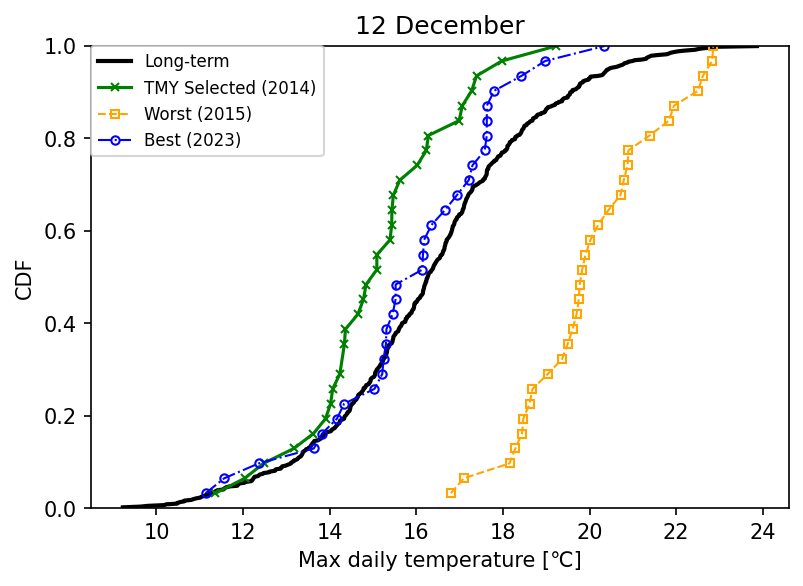

2005  min_temp


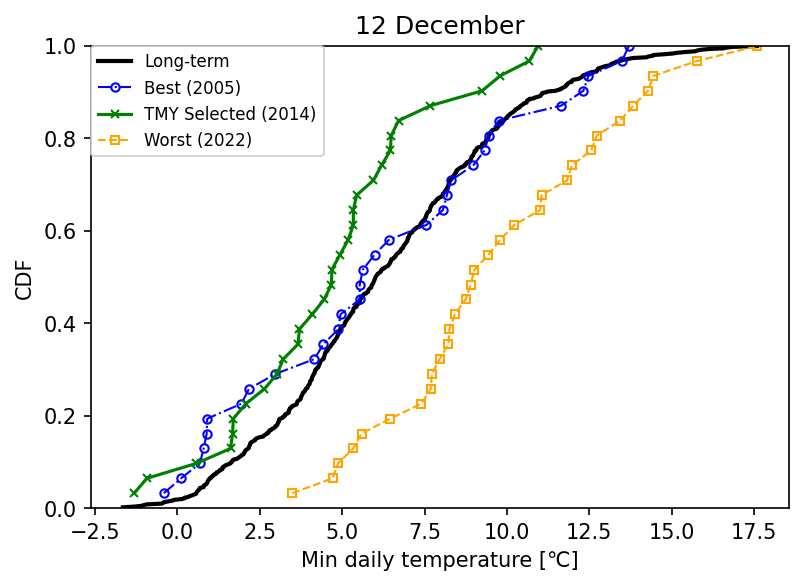

2020  temp


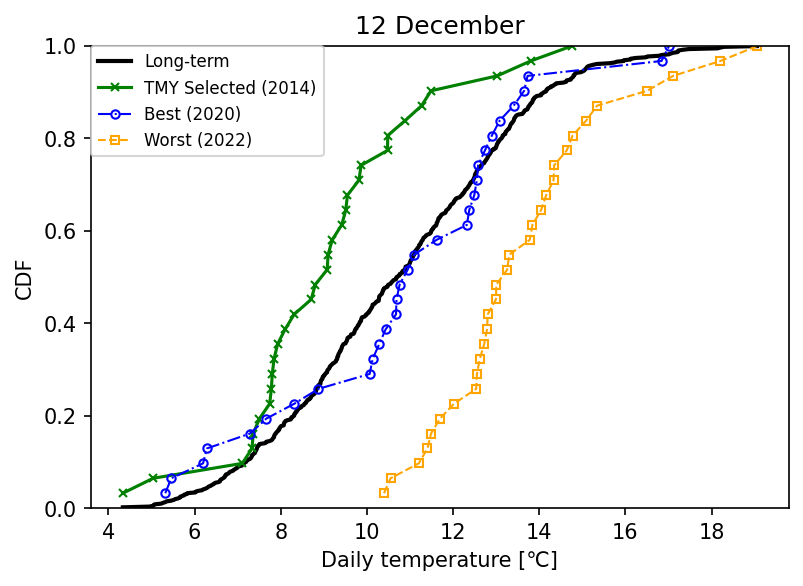

2021  max_dew_temp


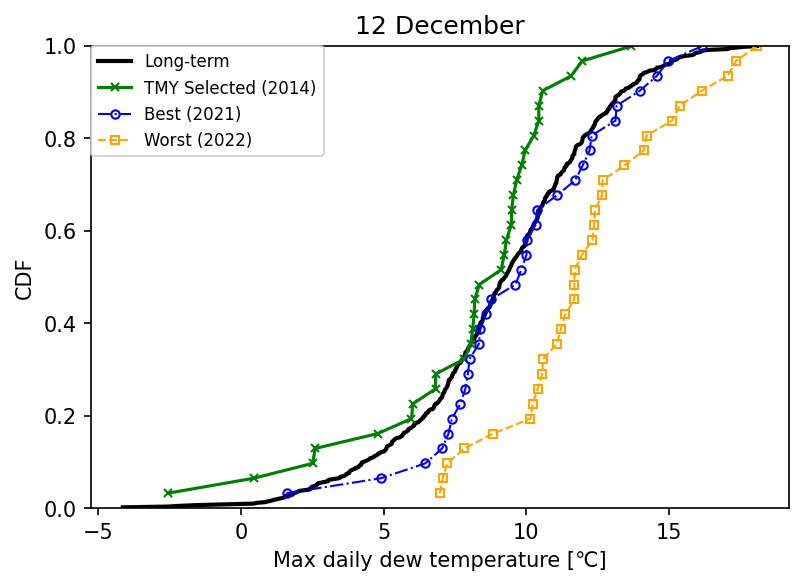

2012  min_dew_temp


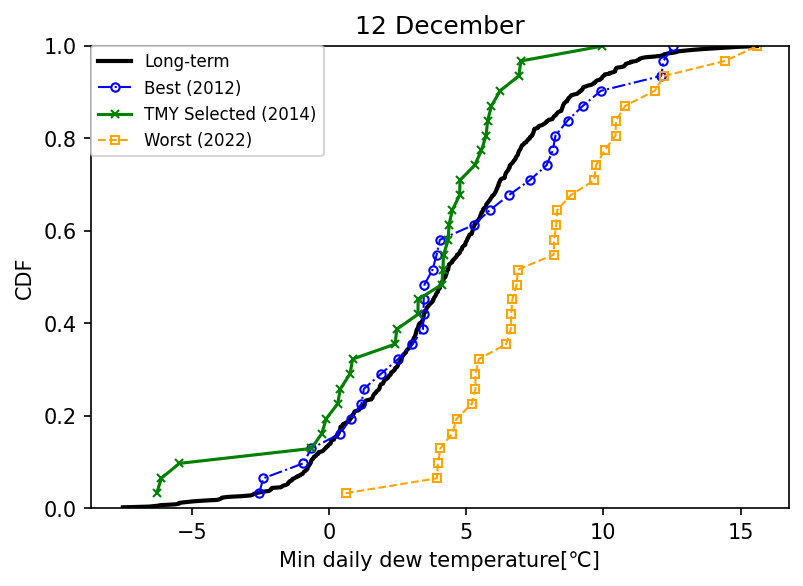

2021  dew_temp


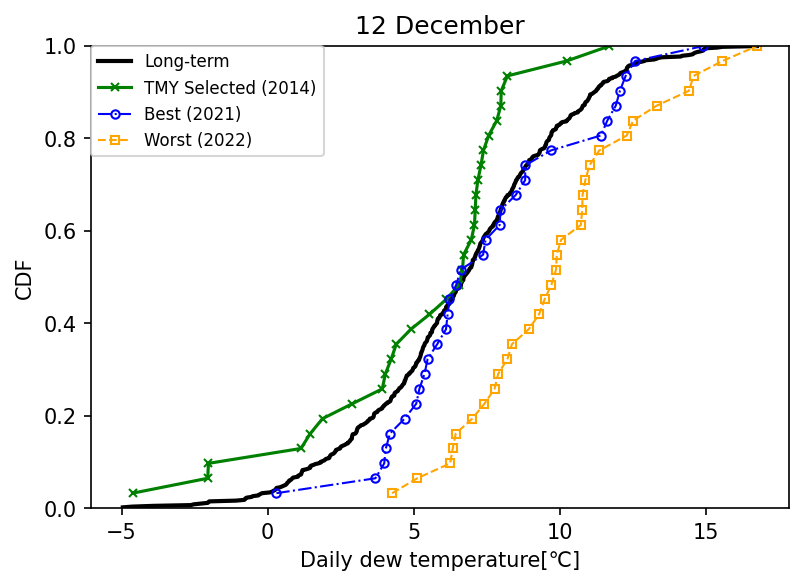

2013  max_wind_speed


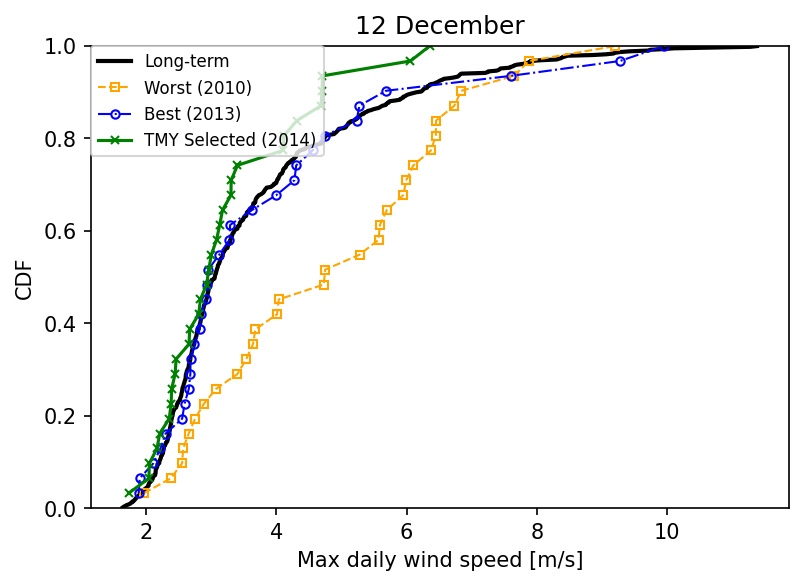

2013  wind_speed


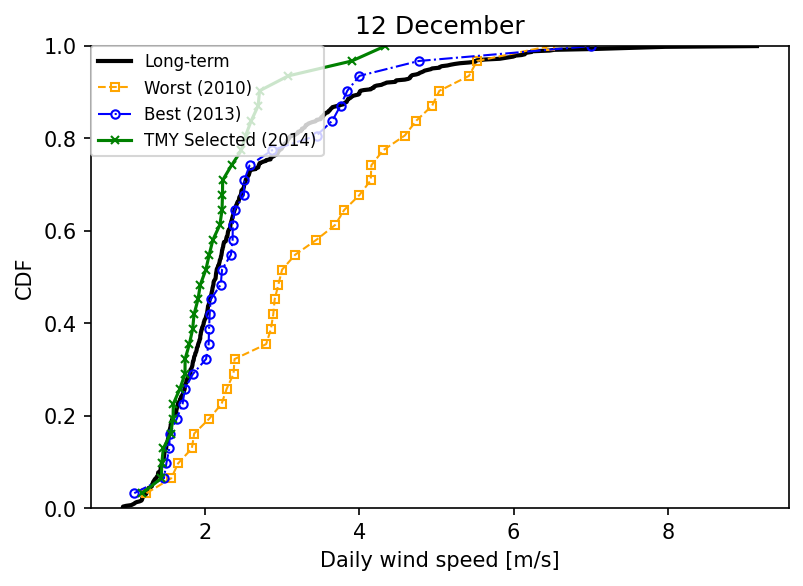

2005  global_horiz_radiation


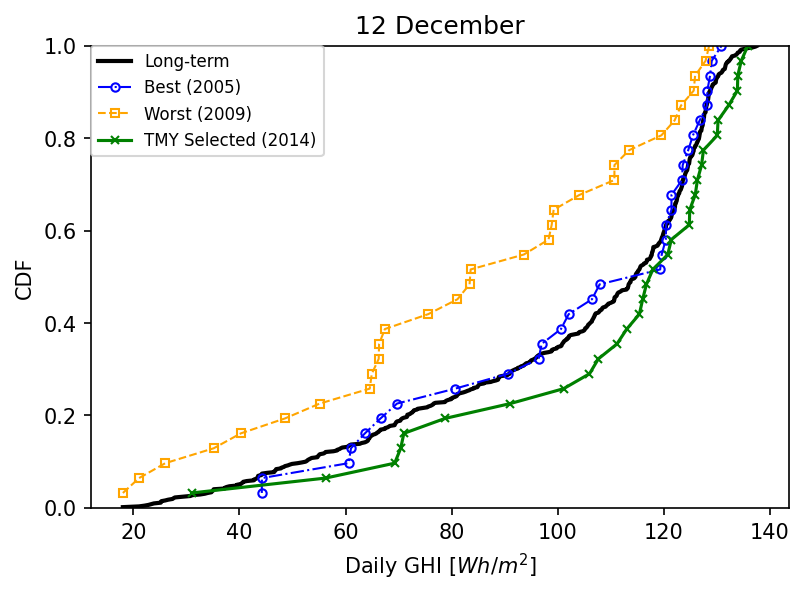

2005  direct_normal_radiation


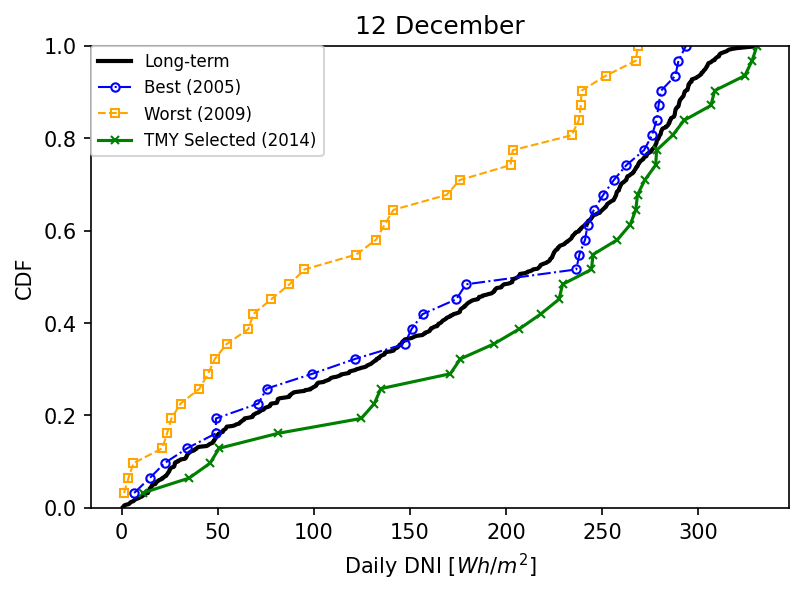

In [38]:
testpath = rf"{TMYs_folder}/{site_name}/plot/"
if not os.path.exists(testpath):
    os.makedirs(testpath)
plotCdfs(df, 12, config, 2014, daily=True, save=True, pathfig=testpath)

### les scénarios P75 Pxx

In [39]:
dataset['Year'] = dataset.index.year
# Group by 'Year' and sum GHI for each year
yearly_gti = dataset.groupby('Year')[['GHI', 'DNI']].sum().reset_index()

# Convert to kWh/m² (since GHI is usually in W/m² and there are 8760 hours in a year)
yearly_gti[['GHI', 'DNI']] = yearly_gti[['GHI', 'DNI']] / 1000

In [40]:
yearly_gti

,Year,GHI,DNI
0,2005,1937.903073,2325.197915
1,2006,1816.402240,2020.354810
2,2007,1856.706067,2162.724795
3,2008,1871.521769,2160.614045
4,2009,1891.334764,2183.604316
5,2010,1834.973486,2046.697228
6,2011,1892.619806,2241.452597
7,2012,1935.416885,2380.559672
8,2013,1899.006922,2277.257083
9,2014,1910.586886,2285.207818


In [41]:
# Function to calculate Pxx values
def calculate_pxx(p50, uncertainty, xx):
    z_score = {75: 0.675, 90: 1.282, 99: 2.326}
    result = p50 * (1 - z_score[xx] * uncertainty)
    result = result.clip(lower=0)  # Ensure all values are positive
    return result.astype(int)  # Convert to integer

In [42]:
columns_of_interest = ['GHI', 'DNI']
# Calculate standard deviation and relative uncertainty for each column
std_dev = {}
relative_uncertainty = {}
for column in columns_of_interest:
    std_dev[column] = yearly_gti[column].std()
    relative_uncertainty[column] = std_dev[column] / yearly_gti[column].mean()

In [43]:
std_dev

{'GHI': np.float64(43.14202776718291), 'DNI': np.float64(124.65057361480943)}

In [44]:
relative_uncertainty

{'GHI': np.float64(0.022654317098051956),
 'DNI': np.float64(0.05491596344368572)}

In [45]:
# Calculate P75, P90, and P99 for each specified column
artificial_df = pd.DataFrame(index=df_TMY.index)
for column in columns_of_interest:
    artificial_df[f'{column}_P50'] = df_TMY[column]   #TMY data
    artificial_df[f'{column}_P75'] = calculate_pxx(df_TMY[column], relative_uncertainty[column], 75)
    artificial_df[f'{column}_P90'] = calculate_pxx(df_TMY[column], relative_uncertainty[column], 90)
    artificial_df[f'{column}_P99'] = calculate_pxx(df_TMY[column], relative_uncertainty[column], 99)

In [46]:
sum_artf_df = pd.DataFrame(artificial_df.sum(axis=0) / 1000).transpose()

In [47]:
sum_artf_df

,GHI_P50,GHI_P75,GHI_P90,GHI_P99,DNI_P50,DNI_P75,DNI_P90,DNI_P99
0,1900.3246,1868.917,1842.767,1797.828,2275.202791,2188.624,2112.776,1982.365


In [48]:
# Define the three scenarios and their corresponding columns
scenarios = {
    'P75': 'GHI_P75',
    'P90': 'GHI_P90',
    'P99': 'GHI_P99'
}

# Dictionary to store closest years for each scenario
closest_years = {}

# Iterate through each scenario
for scenario, column in scenarios.items():
    # Get the value for the current scenario from sum_art_df
    comparison_value = sum_artf_df[column].iloc[0]

    # Calculate the absolute distance for each year
    yearly_gti[f'Distance_{scenario}'] = yearly_gti['GHI'].apply(
        lambda x: abs(x - comparison_value)
    )

    # Find the closest year for the current scenario
    closest_year = yearly_gti.loc[yearly_gti[f'Distance_{scenario}'].idxmin(), 'Year']
    closest_years[scenario] = closest_year

# Print the closest years for each scenario
for scenario, year in closest_years.items():
    print(f"The closest year for {scenario} is {year}")


The closest year for P75 is 2008
The closest year for P90 is 2010
The closest year for P99 is 2006


In [49]:
yearly_gti

,Year,GHI,DNI,Distance_P75,Distance_P90,Distance_P99
0,2005,1937.903073,2325.197915,68.986073,95.136073,140.075073
1,2006,1816.402240,2020.354810,52.514760,26.364760,18.574240
2,2007,1856.706067,2162.724795,12.210933,13.939067,58.878067
3,2008,1871.521769,2160.614045,2.604769,28.754769,73.693769
4,2009,1891.334764,2183.604316,22.417764,48.567764,93.506764
5,2010,1834.973486,2046.697228,33.943514,7.793514,37.145486
6,2011,1892.619806,2241.452597,23.702806,49.852806,94.791806
7,2012,1935.416885,2380.559672,66.499885,92.649885,137.588885
8,2013,1899.006922,2277.257083,30.089922,56.239922,101.178922
9,2014,1910.586886,2285.207818,41.669886,67.819886,112.758886


In [50]:
closest_years

{'P75': np.int32(2008), 'P90': np.int32(2010), 'P99': np.int32(2006)}

In [51]:
df_p75 = dataset.loc[str(closest_years['P75'])]
df_p90 = dataset.loc[str(closest_years['P90'])]
df_p99 = dataset.loc[str(closest_years['P99'])]

In [52]:
df_p75.to_csv(f'{TMYs_folder}/{site_name}/{site_name}_TMY_P75.csv', index=True)
df_p90.to_csv(f'{TMYs_folder}/{site_name}/{site_name}_TMY_P90.csv', index=True)
df_p99.to_csv(f'{TMYs_folder}/{site_name}/{site_name}_TMY_P99.csv', index=True)

In [53]:
df_p75_monthly = df_p75[['GHI', 'DNI','GTI']].resample('ME').sum()  / 1000
df_p90_monthly = df_p90[['GHI', 'DNI','GTI']].resample('ME').sum() / 1000
df_p99_monthly = df_p99[['GHI', 'DNI','GTI']].resample('ME').sum() / 1000
tmy_df_rad = df_TMY[['GHI', 'DNI','GTI']]
tmy_df_rad.index = tmy_df_rad.index.map(lambda x: x.replace(year=2050))
tmy_df_rad_month = tmy_df_rad.resample('ME').sum() /1000

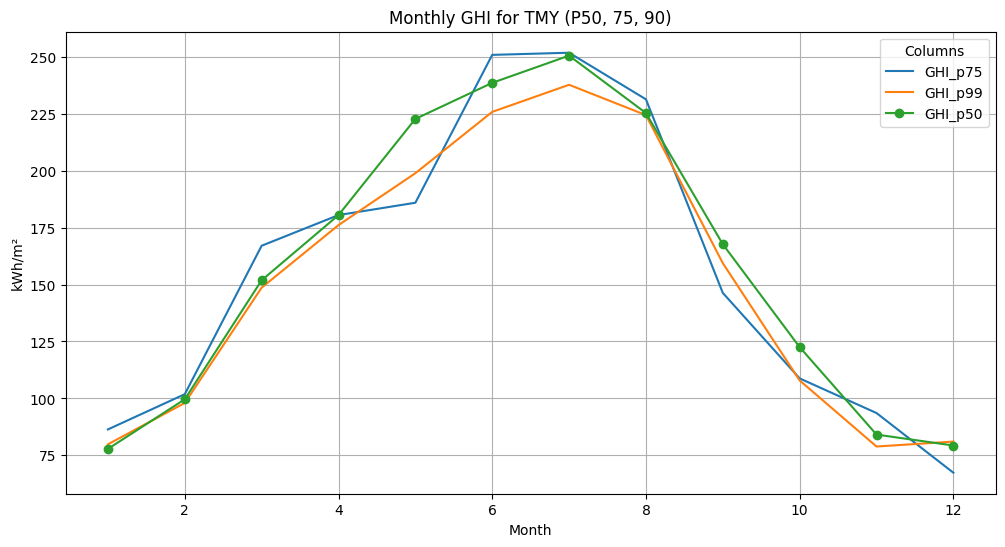

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

var = 'GHI'
months = [1,2,3,4,5,6,7,8,9,10,11,12]
plt.figure(figsize=(12, 6))
plt.plot(months, df_p75_monthly[var], label = f'{var}_p75')
#plt.plot(months, df_p90_monthly[var], label = f'{var}_p90')
plt.plot(months, df_p99_monthly[var], label = f'{var}_p99')
plt.plot(months, tmy_df_rad_month[var], label = f'{var}_p50', marker='o')

plt.title(f'Monthly {var} for TMY (P50, 75, 90)')
plt.xlabel('Month')
plt.ylabel('kWh/m²')
plt.grid(True)
plt.legend(title='Columns')
#plt.savefig(r"C:\Users\DELL\Desktop\TMY\beng vs soda report tmy\Monthly_ghi_pxx.png")
plt.show()

In [55]:
tmy_df_rad_month.index = tmy_df_rad_month.index.month
df_p75_monthly.index = df_p75_monthly.index.month
df_p90_monthly.index = df_p90_monthly.index.month
df_p99_monthly.index = df_p99_monthly.index.month

In [56]:
concat_monthly = pd.concat([tmy_df_rad_month[['GHI', 'DNI','GTI']].add_suffix('_P50'),
                           df_p75_monthly[['GHI','DNI','GTI']].add_suffix('_P75'),
                           df_p90_monthly[['GHI','DNI','GTI']].add_suffix('_P90'),
                           df_p99_monthly[['GHI','DNI','GTI']].add_suffix('_P99')], axis=1)

In [57]:
#concat_monthly
month_names = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

concat_monthly_rounded = concat_monthly.round().astype(int)

# Replace the index with month names
concat_monthly_rounded.index = month_names
concat_monthly_rounded.loc["Yearly"] = concat_monthly_rounded.sum()


concat_monthly_rounded.to_csv(f'{TMYs_folder}/{site_name}/concat_monthly_rounded_{site_name}.csv', index=True)
concat_monthly_rounded

,GHI_P50,DNI_P50,GTI_P50,GHI_P75,DNI_P75,GTI_P75,GHI_P90,DNI_P90,GTI_P90,GHI_P99,DNI_P99,GTI_P99
January,78,123,116,86,145,131,68,84,92,80,133,121
February,100,138,131,102,127,133,80,86,100,98,121,127
March,152,175,177,167,207,197,133,127,149,149,166,173
April,180,188,187,180,188,187,181,170,189,176,159,183
May,223,224,214,186,138,178,235,251,226,199,166,191
June,239,254,221,251,278,230,231,238,212,226,217,210
July,250,283,235,252,279,237,249,273,234,238,254,224
August,225,261,229,231,273,235,217,235,220,224,257,229
September,168,200,190,146,143,160,170,204,193,159,169,178
October,122,147,154,109,117,133,127,165,162,108,118,131


In [58]:
dataset_monthly = dataset[['GHI','DNI','GTI']].resample('ME').sum() / 1000

In [59]:
dataset_monthly['Month'] = dataset_monthly.index.month_name()

In [60]:
dataset_monthly

,GHI,DNI,GTI,Month
datetime_x,,,,
2005-01-31,98.524373,199.515251,160.550260,January
2005-02-28,109.161373,174.639550,151.457568,February
2005-03-31,140.433382,130.977756,156.935803,March
2005-04-30,197.475852,217.814902,205.795695,April
2005-05-31,221.986316,223.753691,214.251230,May
...,...,...,...,...
2024-08-31,231.193673,279.217931,235.097843,August
2024-09-30,169.578128,205.981306,192.054796,September
2024-10-31,106.905973,120.544820,131.043772,October


<Figure size 1200x600 with 0 Axes>

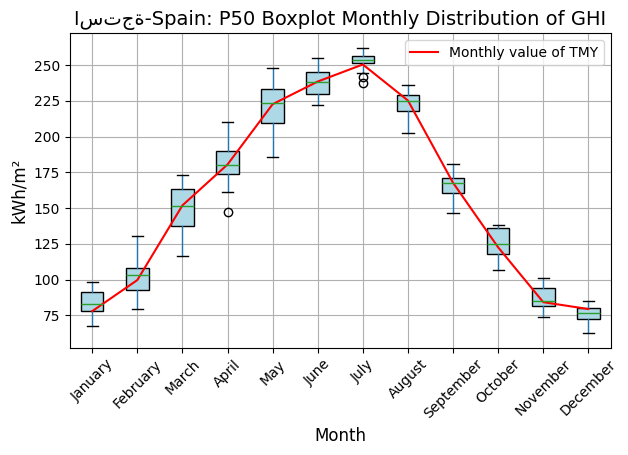

In [61]:
datatoplot = concat_monthly
scenario = 'P50'
var = 'GHI'
var_abrv = {'GHI': 'GHI', 'DNI': 'DNI'}

dataset_monthly['Month'] = pd.Categorical(dataset_monthly.index.strftime('%B'), categories=[
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
], ordered=True)

plt.figure(figsize=(12, 6))
dataset_monthly.boxplot(column=var, by='Month', grid=False, showfliers=True, patch_artist=True,
           boxprops=dict(facecolor="lightblue"))
plt.plot(datatoplot.index, datatoplot[f'{var}_{scenario}'], label = f'Monthly value of TMY', color = 'red')

# Adjusting the plot aesthetics
plt.title(f"{site_name}: {scenario} Boxplot Monthly Distribution of {var_abrv[var]}", fontsize=14)
plt.suptitle("")  # Removing the automatic subtitle generated by boxplot
plt.xlabel("Month", fontsize=12)
plt.ylabel("kWh/m²", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
# Show the plot
plt.tight_layout()
plt.savefig(rf"{TMYs_folder}/{site_name}/plot/boxplot_{var}_{scenario}.png")
plt.show()

In [62]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd

# Define the scenarios and variables
scenarios = ['P50', 'P75', 'P90', 'P99']
var = 'GHI'
var_abrv = {'GHI': 'GHI', 'DNI': 'DNI'}
datatoplot = concat_monthly

# Ensure 'Month' is categorical for sorting purposes
dataset_monthly['Month'] = pd.Categorical(dataset_monthly.index.strftime('%B'), categories=[
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
], ordered=True)

# Create subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Loop through scenarios and assign each to a subplot
for ax, scenario in zip(axes.flatten(), scenarios):
    dataset_monthly.boxplot(column=var, by='Month', grid=False, showfliers=True, patch_artist=True,
                            boxprops=dict(facecolor="lightblue"), ax=ax)
    
    # Overlay the scenario line plot
    ax.plot(datatoplot.index, datatoplot[f'{var}_{scenario}'], label=f'{scenario} Monthly Value', color='red')

    # Adjusting the plot aesthetics
    ax.set_title(f"{site_name}: {scenario} Boxplot Monthly Distribution of {var_abrv[var]}", fontsize=12)
    ax.set_xlabel("Month", fontsize=10)
    ax.set_ylabel("kWh/m²", fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)
    ax.legend()
plt.suptitle("")
# Adjust layout for better spacing
plt.tight_layout()

# Save and show the plot
plt.savefig(rf"{TMYs_folder}/{site_name}/plot/boxplot_{var}.png")
plt.show()


### File output

#### PVGIS

In [63]:
altitude = pvlib.location.lookup_altitude(latitude=lat, longitude=lon)
metadata = {
    'Latitude (decimal degrees)': lat,
    'Longitude (decimal degrees)': lon,
    'Elevation (m)': altitude
}
columns_to_select = {
    'datetime_x': 'time(UTC)',
    'Temperature': 'T2m',
    'Relative Humidity': 'RH',
    'GHI': 'G(h)',
    'DNI': 'Gb(n)',
    'DHI': 'Gd(h)',
    #'Reflected': 'IR(h)',
    'GTI': 'G(t)',
    'Wind Speed': 'WS10m',
    'Wind Direction': 'WD10m',
    'Pressure': 'SP'
}

glossary_lines = [
    "T2m: 2-m air temperature (degree Celsius)",
    "RH: relative humidity (%)",
    "G(h): Global irradiance on the horizontal plane (W/m2)",
    "Gb(n): Beam/direct irradiance on a plane always normal to sun rays (W/m2)",
    "Gd(h): Diffuse irradiance on the horizontal plane (W/m2)",
    #"IR(h): Surface infrared (thermal) irradiance on a horizontal plane (W/m2)",
    "G(t): Global irradiance on a tilted plane (W/m2)",
    "WS10m: 10-m total wind speed (m/s)",
    "WD10m: 10-m wind direction (0 = N, 90 = E) (degree)",
    "SP: Surface (air) pressure (Pa)",
    "",
    "Green Energy Park (c), 2025"
]

In [64]:
import os
dfs_to_files= {
    'P50' : df_TMY,
    'P75' : df_p75,
    'P90' : df_p90,
    'P99' : df_p99,   
}
path = f"{TMYs_folder}/{site_name}/tmy_files"
def generate_tmy_files_pvGIS(dfs, path, metadata,glossary_lines,columns_to_select,lon,lat):
    if not os.path.exists(path):
        os.makedirs(path)
    for scenario, df in dfs.items():
        df['datetime_x'] = df.index
        pvgis_df = df[list(columns_to_select.keys())].rename(columns=columns_to_select)
        
        pvgis_df['time(UTC)'] = pd.to_datetime(pvgis_df['time(UTC)'], format='%Y-%m-%d %H:%M:%S')
        unique_month_year = pvgis_df['time(UTC)'].dt.strftime('%m,%Y').unique()
        month_year_lines = [f"{month_year}" for month_year in unique_month_year]
        pvgis_df['time(UTC)'] = pvgis_df['time(UTC)'].dt.strftime('%Y%m%d:%H%M')
        
        metadata_lines = [f"{key} : {value}" for key, value in metadata.items()]
        
        new_csv_path = f'{path}/TMY_{scenario}_pvgis_{lon}_{lat}.csv'
        
        with open(new_csv_path, 'w', newline='') as f:
            # Write each metadata line at the top of the file
            for line in metadata_lines:
                f.write(f"{line}\n")
            
            f.write("month,year\n")
            for line in month_year_lines:
                f.write(f"{line}\n")
        
            pvgis_df.to_csv(f, index=False)
        
            f.write("\n") 
            for line in glossary_lines:
                f.write(f"{line}\n")
            f.write("\n")
            print(f'{scenario} was generated successfully!')

In [65]:
generate_tmy_files_pvGIS(dfs_to_files, path, metadata,glossary_lines,columns_to_select,lon,lat)

P50 was generated successfully!


P75 was generated successfully!


P90 was generated successfully!


P99 was generated successfully!


#### PVsyst

In [66]:
metadata = [
"#Meteo hourly data",													
f"#Site,{site_name}",													
"#Country,Morocco",												
"#Data Source,Cams Solar radiations and ERA5 for meteorological data",												
"#Time step,Hour",												
"#Year,2050",											
f"#Latitude,{lat}",												
f"#Longitude,{lon}",												
f"#Altitude,{altitude}",												
"#Time zone,UTC+01:00",											
"#Plane tilt,30",																				
]

columns_to_select_pvsyst = {
    'datetime_x': 'time(UTC)',
    'GHI': 'GHI',
    'DHI': 'DHI',
    'DNI': 'DNI',
    'GTI': 'GPI',
    'Temperature': 'Tamb',
    'Wind Speed': 'WindVel',
    'Pressure': 'Press',
    'Relative Humidity': 'RelHum',
}

In [67]:
#old function
dfs_to_files= {
    'P50' : df_TMY,
    'P75' : df_p75,
    'P90' : df_p90,
    'P99' : df_p99,   
}
path = f"{TMYs_folder}/{site_name}/tmy_files"

def generate_tmy_pvsyst(dfs_to_files, path, metadata,glossary_lines,columns_to_select,lon,lat):
    if not os.path.exists(path):
        os.makedirs(path)
    for scenario, df in dfs_to_files.items():
        df_copy = df.copy(deep=True)
        if scenario == 'P50':
            df_copy.index = df_copy.index.map(lambda x: x.replace(year=2050))
            metadata[5] = f"#Year,2050"
        else:
            metadata[5] = str(df.index.year[0])
        
        df_copy['datetime_x'] = df_copy.index
        df_copy = df_copy[list(columns_to_select_pvsyst.keys())].rename(columns=columns_to_select_pvsyst)
        df_copy['time(UTC)'] = pd.to_datetime(df_copy['time(UTC)'])
        #getting dates
        df_copy['Year'] = df_copy['time(UTC)'].dt.year
        df_copy['Month'] = df_copy['time(UTC)'].dt.month
        df_copy['Day'] = df_copy['time(UTC)'].dt.day
        df_copy['Hour'] = df_copy['time(UTC)'].dt.hour
        df_copy['Minute'] = df_copy['time(UTC)'].dt.minute
        
        #deleting date col
        df_copy.drop(columns=['time(UTC)'], inplace=True)
        
        #reorder cols
        
        new_column_order = ['Year','Month', 'Day', 'Hour', 'Minute','GHI','DHI','DNI','GPI','Tamb','WindVel','Press','RelHum']
        df_copy = df_copy[new_column_order]
        
        pvsyst_csv_path = f'{path}/TMY_{scenario}_PVsyst_{lon}_{lat}.csv'

        
        with open(pvsyst_csv_path, 'w', newline='') as f:
            for line in metadata:
                f.write(f'{line}\n')
            df_copy.to_csv(f, index=False)
        print(f'{scenario} was generated successfully!')

In [68]:
        #print(df_copy)
        #unit_row = pd.DataFrame([['', '', '', '', '','', 'W/m2', 'W/m2','W/m2','W/m2', 'deg.C', 'm/s','mb', '%' ]], columns=df_copy.columns)
        #df_copy_concat = pd.concat([unit_row, df_copy], ignore_index=True)
        #df_copy.loc[-1] = ['', '', '', '', '','', 'W/m2', 'W/m2','W/m2','W/m2', 'deg.C', 'm/s','mb', '%' ]
        #df_copy = df.sort_index().reset_index(drop=True)

In [69]:
def generate_tmy_pvsyst(dfs_to_files, path, metadata, glossary_lines, columns_to_select, lon, lat):
    if not os.path.exists(path):
        os.makedirs(path)
    
    # Define units for each column
    units_row = {
        'Year': '',
        'Month': '',
        'Day': '',
        'Hour': '',
        'Minute': '',
        'GHI': 'W/m2',
        'DHI': 'W/m2',
        'DNI': 'W/m2',
        'GPI': 'W/m2',
        'Tamb': 'deg.C',
        'WindVel': 'm/s',
        'Press': 'mb',
        'RelHum': '%'
    }
    
    for scenario, df in dfs_to_files.items():
        df_copy = df.copy(deep=True)
        if scenario == 'P50':
            df_copy.index = df_copy.index.map(lambda x: x.replace(year=2050))
            metadata[5] = f"#Year,2050"
        else:
            metadata[5] = str(df.index.year[0])
        
        df_copy['datetime_x'] = df_copy.index
        df_copy = df_copy[list(columns_to_select_pvsyst.keys())].rename(columns=columns_to_select_pvsyst)
        df_copy['time(UTC)'] = pd.to_datetime(df_copy['time(UTC)'])
        
        # Getting dates
        df_copy['Year'] = df_copy['time(UTC)'].dt.year
        df_copy['Month'] = df_copy['time(UTC)'].dt.month
        df_copy['Day'] = df_copy['time(UTC)'].dt.day
        df_copy['Hour'] = df_copy['time(UTC)'].dt.hour
        df_copy['Minute'] = df_copy['time(UTC)'].dt.minute
        
        # Deleting date col
        df_copy.drop(columns=['time(UTC)'], inplace=True)
        
        # Reorder cols
        new_column_order = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'GHI', 'DHI', 'DNI', 'GPI', 'Tamb', 'WindVel', 'Press', 'RelHum']
        df_copy = df_copy[new_column_order]
        
        pvsyst_csv_path = f'{path}/TMY_{scenario}_PVsyst_{lon}_{lat}.csv'
        
        with open(pvsyst_csv_path, 'w', newline='') as f:
            # Write metadata
            for line in metadata:
                f.write(f'{line}\n')
            
            # Write column headers
            f.write(','.join(new_column_order) + '\n')
            
            # Write units row
            units_line = ','.join(units_row[col] for col in new_column_order)
            f.write(units_line + '\n')
            
            # Write the data without header since we've already written it
            df_copy.to_csv(f, index=False, header=False)
            
        print(f'{scenario} was generated successfully!')

In [70]:
generate_tmy_pvsyst(dfs_to_files, path, metadata,glossary_lines,columns_to_select,lon,lat)

P50 was generated successfully!


P75 was generated successfully!


P90 was generated successfully!


P99 was generated successfully!


#### SAM

In [71]:
nsrdb_metadata = [
    'Source,Location ID,City,State,Country,Latitude,Longitude,Time Zone,Elevation,Local Time Zone,Clearsky DHI Units,Clearsky DNI Units,Clearsky GHI Units,Dew Point Units,DHI Units,DNI Units,GHI Units,Solar Zenith Angle Units,Temperature Units,Pressure Units,Relative Humidity Units,Precipitable Water Units,Wind Direction Units,Wind Speed Units,Cloud Type -15,Cloud Type 0,Cloud Type 1,Cloud Type 2,Cloud Type 3,Cloud Type 4,Cloud Type 5,Cloud Type 6,Cloud Type 7,Cloud Type 8,Cloud Type 9,Cloud Type 10,Cloud Type 11,Cloud Type 12,Fill Flag 0,Fill Flag 1,Fill Flag 2,Fill Flag 3,Fill Flag 4,Fill Flag 5,Surface Albedo Units,Version',
    f'Green Energy Park,-,{site_name},-,Morocco,{lat},{lon},UTC+0,{altitude},UTC+1,w/m2,w/m2,w/m2,c,w/m2,w/m2,w/m2,Degree,c,mbar,%,cm,Degrees,m/s,N/A,Clear,Probably Clear,Fog,Water,Super-Cooled Water,Mixed,Opaque Ice,Cirrus,Overlapping,Overshooting,Unknown,Dust,Smoke,N/A,Missing Image,Low Irradiance,Exceeds Clearsky,Missing CLoud Properties,Rayleigh Violation,N/A,4.0.0'
]

columns_to_select_SAM = {
    'datetime_x': 'time(UTC)',
    'DNI': 'DNI',
    'DHI': 'DHI',
    'GHI': 'GHI',
    'Dew Point' : 'Dew Point',
    'Temperature': 'Temperature',
    'Pressure': 'Pressure',
    'Wind Direction':'Wind Direction',
    'Wind Speed': 'Wind Speed',
    'Relative Humidity': 'Relative Humidity',
}

dfs_to_files= {
    'P50' : df_TMY,
    'P75' : df_p75,
    'P90' : df_p90,
    'P99' : df_p99,   
}
path = f"{TMYs_folder}/{site_name}/tmy_files"

def generate_tmy_files_SAM(dfs, path, metadata,glossary_lines,columns_to_select,lon,lat):
    if not os.path.exists(path):
        os.makedirs(path)
    for scenario, df in dfs.items():
        df_sam = df.copy(deep=True)
        df_sam['datetime_x'] = df_sam.index
        df_sam = df_sam[list(columns_to_select.keys())].rename(columns=columns_to_select)
        df_sam['time(UTC)'] = pd.to_datetime(df_sam['time(UTC)'], format='%Y-%m-%d %H:%M:%S')
        df_sam['Year'] = df_sam['time(UTC)'].dt.year
        df_sam['Month'] = df_sam['time(UTC)'].dt.month
        df_sam['Day'] = df_sam['time(UTC)'].dt.day
        df_sam['Hour'] = df_sam['time(UTC)'].dt.hour
        df_sam['Minute'] = df_sam['time(UTC)'].dt.minute
        df_sam.drop(columns=['time(UTC)'], inplace=True)
        df_sam = df_sam[['Year', 'Month', 'Day', 'Hour', 'Minute','DNI', 'DHI', 'GHI', 'Dew Point', 
                         'Temperature','Pressure','Wind Direction','Wind Speed','Relative Humidity']]
        
        metadata_lines = metadata
        
        new_csv_path = f'{path}/TMY_{scenario}_SAM_{lon}_{lat}.csv'
        
        with open(new_csv_path, 'w', newline='') as f:
            # Write each metadata line at the top of the file
            for line in metadata_lines:
                f.write(f"{line}\n")
        
            df_sam.to_csv(f, index=False)
            print(f'{scenario} was generated successfully!')


In [72]:
generate_tmy_files_SAM(dfs_to_files, path, nsrdb_metadata,glossary_lines,columns_to_select_SAM,lon,lat)

P50 was generated successfully!


P75 was generated successfully!


P90 was generated successfully!


P99 was generated successfully!


In [73]:
df_TMY

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,DHI,DNI,Temperature,Dew Point,...,Pressure,Surface solar radiation downwards,datetime_y,min_temp,max_temp,min_dew,max_dew,max_wind_speed,GTI,datetime_x
datetime_x,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.19680,7.07137,...,1034.18060,0.0,2018-01-01,5.06740,16.08587,2.44735,7.07137,3.058533,0.0,2018-01-01 00:00:00
2018-01-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.62533,6.78845,...,1034.23810,0.0,2018-01-01,5.06740,16.08587,2.44735,7.07137,3.058533,0.0,2018-01-01 01:00:00
2018-01-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.14640,6.36404,...,1034.12940,0.0,2018-01-01,5.06740,16.08587,2.44735,7.07137,3.058533,0.0,2018-01-01 02:00:00
2018-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.83108,4.56234,...,1034.03810,0.0,2018-01-01,5.06740,16.08587,2.44735,7.07137,3.058533,0.0,2018-01-01 03:00:00
2018-01-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.95170,4.15133,...,1033.95375,0.0,2018-01-01,5.06740,16.08587,2.44735,7.07137,3.058533,0.0,2018-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-12-31 19:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.09408,6.30123,...,1028.89375,0.0,2016-12-31,4.72543,15.15286,4.03884,8.06040,2.682827,0.0,2016-12-31 19:00:00
2016-12-31 20:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.03848,5.99750,...,1029.20625,0.0,2016-12-31,4.72543,15.15286,4.03884,8.06040,2.682827,0.0,2016-12-31 20:00:00
2016-12-31 21:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.28344,5.50510,...,1029.26440,0.0,2016-12-31,4.72543,15.15286,4.03884,8.06040,2.682827,0.0,2016-12-31 21:00:00


### Generating reports assets

### taking unique years

In [74]:
df_TMY['datetime_y'] = pd.to_datetime(df_TMY['datetime_y'], errors='coerce')
unique_month_year = df_TMY['datetime_y'].dt.strftime('%m,%Y').unique()
unique_year = [e.split(',')[1] for e in unique_month_year]

months = ["Jan.", "Feb.", "Mar.", "Apr.", "May", "Jun.", "Jul.", "Aug.", "Sept.", "Oct.", "Nov.", "Dec."]
chosen_years_table = pd.DataFrame(
    {
        "Month" : months,
        "P50" : unique_year,
        "P75" : [str(closest_years['P75'])]*12,
        "P90" : [str(closest_years['P90'])]*12,
        "P99" : [str(closest_years['P99'])]*12
    }
)

chosen_years_table

,Month,P50,P75,P90,P99
0,Jan.,2018,2008,2010,2006
1,Feb.,2009,2008,2010,2006
2,Mar.,2017,2008,2010,2006
3,Apr.,2008,2008,2010,2006
4,May,2017,2008,2010,2006
5,Jun.,2021,2008,2010,2006
6,Jul.,2017,2008,2010,2006
7,Aug.,2022,2008,2010,2006
8,Sept.,2023,2008,2010,2006
9,Oct.,2016,2008,2010,2006


In [75]:
import matplotlib.pyplot as plt
import numpy as np

var = 'DNI'

dataset_yearly = (dataset[['GHI', 'DNI', 'GTI']].resample('YE').sum() / 1000).round(0).astype(int)

# Extract TMY values from the "Yearly" row in concat_monthly_rounded DataFrame
tmy_values = concat_monthly_rounded.loc["Yearly"].to_dict()

# Create a 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Define scenarios and corresponding axes
scenarios = ["P50", "P75", "P90", "P99"]
axes = axes.flatten()  # Flatten the 2x2 array for easy iteration

# Loop through scenarios and plot on respective subplot
for i, scenario in enumerate(scenarios):
    ax = axes[i]
    
    # Bar plot for yearly GHI values
    ax.bar(dataset_yearly.index.year, dataset_yearly[var], color="lightblue", label="LT")
    
    # Add TMY as a horizontal red line from the "Yearly" row
    ax.axhline(y=tmy_values[f'{var}_{scenario}'], color="red", linewidth=3, label="TMY")
    
    # Set titles and labels
    ax.set_title(f"{site_name}: {scenario} Yearly {var} histogram comparison", fontsize=12)
    ax.set_xlabel("Year")
    ax.set_ylabel("KWh/m²")

    ax.set_xticks(dataset_yearly.index.year)  # Set all years as X-ticks
    ax.tick_params(axis='x', rotation=45)  # Rotate labels for better readability

    max_value = dataset_yearly[var].max() + 50  # Add margin to max value
    ax.set_ylim(1950, max_value)
    
    # Add legend
    ax.legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Save and show the figure
plt.savefig(f"{TMYs_folder}/{site_name}/plot/{site_name}_yearly_{var}_comparison.png", dpi=300)
plt.show()


In [76]:
def plot_yearly_comparison(dataset, concat_monthly_rounded, site_name, var):
    """
    Generates a yearly bar plot comparing historical data with TMY (P50, P75, P90, P99) values.

    Parameters:
    - dataset (pd.DataFrame): Original dataset with GHI, DNI, and GTI values.
    - concat_monthly_rounded (pd.DataFrame): Data containing the "Yearly" row with TMY values.
    - site_name (str): Name of the site for saving the plot.
    - var (str): Variable to plot ('GHI', 'DNI', 'GTI'). Default is 'DNI'.

    Saves the figure and displays it.
    """

    # Compute yearly sums and convert to kWh/m²
    dataset_yearly = (dataset[['GHI', 'DNI', 'GTI']].resample('YE').sum() / 1000).round(0).astype(int)

    # Extract TMY values from the "Yearly" row
    tmy_values = concat_monthly_rounded.loc["Yearly"].to_dict()

    # Create a 2x2 subplot layout
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()  # Flatten array for easy iteration

    # Define scenarios
    scenarios = ["P50", "P75", "P90", "P99"]

    # Loop through scenarios and plot on respective subplot
    for i, scenario in enumerate(scenarios):
        ax = axes[i]

        # Bar plot for yearly values
        ax.bar(dataset_yearly.index.year, dataset_yearly[var], color="lightblue", label="LT")

        # Add TMY as a horizontal red line
        ax.axhline(y=tmy_values[f'{var}_{scenario}'], color="red", linewidth=3, label="TMY")

        # Set titles and labels
        ax.set_title(f"{site_name}: {scenario} Yearly {var} Histogram Comparison", fontsize=12)
        ax.set_xlabel("Year")
        ax.set_ylabel("kWh/m²")

        # Set all years as X-ticks
        ax.set_xticks(dataset_yearly.index.year)
        ax.tick_params(axis='x', rotation=45)  # Rotate labels for readability

        # Adjust Y-axis limits
        max_value = dataset_yearly[var].max() + 50
        if var =='GHI':
            ax.set_ylim(1750, max_value)
        else:
            ax.set_ylim(1750, max_value)

        # Add legend
        ax.legend()

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Ensure directory exists
    output_dir = os.path.join(TMYs_folder,site_name, "plot")
    os.makedirs(output_dir, exist_ok=True)

    # Save and show the figure
    output_path = os.path.join(output_dir, f"{site_name}_yearly_{var}_comparison.png")
    plt.savefig(output_path, dpi=300)
    plt.show()

    print(f"Plot saved successfully at: {output_path}")

In [77]:
# Example usage:
plot_yearly_comparison(dataset, concat_monthly_rounded, site_name=site_name, var="DNI")
plot_yearly_comparison(dataset, concat_monthly_rounded, site_name=site_name, var="GHI")
plot_yearly_comparison(dataset, concat_monthly_rounded, site_name=site_name, var="GTI")


Plot saved successfully at: TMYs/استجة-Spain/plot/استجة-Spain_yearly_DNI_comparison.png


Plot saved successfully at: TMYs/استجة-Spain/plot/استجة-Spain_yearly_GHI_comparison.png


Plot saved successfully at: TMYs/استجة-Spain/plot/استجة-Spain_yearly_GTI_comparison.png


In [78]:
tmy_values = concat_monthly_rounded.loc["Yearly"].to_dict()
tmy_values

{'GHI_P50': 1900,
 'DNI_P50': 2276,
 'GTI_P50': 2106,
 'GHI_P75': 1871,
 'DNI_P75': 2160,
 'GTI_P75': 2064,
 'GHI_P90': 1836,
 'DNI_P90': 2049,
 'GTI_P90': 1988,
 'GHI_P99': 1817,
 'DNI_P99': 2021,
 'GTI_P99': 2009}

In [79]:
dataset_yearly = (dataset[['GHI', 'DNI', 'GTI']].resample('YE').sum() / 1000).round(0).astype(int)
dataset_yearly

,GHI,DNI,GTI
datetime_x,,,
2005-12-31,1938,2325,2171
2006-12-31,1816,2020,2008
2007-12-31,1857,2163,2063
2008-12-31,1872,2161,2064
2009-12-31,1891,2184,2072
2010-12-31,1835,2047,1987
2011-12-31,1893,2241,2106
2012-12-31,1935,2381,2170
2013-12-31,1899,2277,2116


In [80]:
import os
import matplotlib.pyplot as plt
import pandas as pd

def generate_monthly_boxplots(dataset_monthly, datatoplot, site_name, var='GHI', scenarios=None):
    """
    Generates monthly boxplots for a given variable across multiple scenarios.

    Parameters:
    - dataset_monthly (pd.DataFrame): The dataset containing the monthly values.
    - datatoplot (pd.DataFrame): The dataset containing scenario values.
    - site_name (str): The name of the site.
    - var (str): The variable to plot (e.g., 'GHI', 'DNI'). Default is 'GHI'.
    - scenarios (list): List of scenarios to plot (e.g., ['P50', 'P75', 'P90', 'P99']). Default is ['P50', 'P75', 'P90', 'P99'].

    Saves the plot to the specified directory and displays it.
    """

    # Default scenarios if not provided
    if scenarios is None:
        scenarios = ['P50', 'P75', 'P90', 'P99']
    
    # Variable abbreviation dictionary
    var_abrv = {'GHI': 'GHI', 'DNI': 'DNI', 'GTI':'GTI'}

    # Ensure 'Month' is categorical for proper sorting
    dataset_monthly['Month'] = pd.Categorical(
        dataset_monthly.index.strftime('%B'),
        categories=['January', 'February', 'March', 'April', 'May', 'June',
                    'July', 'August', 'September', 'October', 'November', 'December'],
        ordered=True
    )

    # Create subplots (2x2)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Loop through scenarios and assign each to a subplot
    for ax, scenario in zip(axes.flatten(), scenarios):
        dataset_monthly.boxplot(column=var, by='Month', grid=False, showfliers=True, patch_artist=True,
                                boxprops=dict(facecolor="lightblue"), ax=ax)

        # Overlay the scenario line plot
        ax.plot(datatoplot.index, datatoplot[f'{var}_{scenario}'], label=f'{scenario} Monthly Value', color='red')

        # Adjusting the plot aesthetics
        ax.set_title(f"{site_name}: {scenario} Boxplot Monthly Distribution of {var_abrv[var]}", fontsize=12)
        ax.set_xlabel("Month", fontsize=10)
        ax.set_ylabel("kWh/m²", fontsize=10)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True)
        ax.legend()

    plt.suptitle("")  # Remove default super title
    plt.tight_layout()  # Adjust layout for better spacing

    # Ensure the output directory exists
    output_dir = os.path.join(TMYs_folder,site_name, "plot")
    os.makedirs(output_dir, exist_ok=True)

    # Save and show the plot
    output_path = os.path.join(output_dir, f"boxplot_{var}.png")
    plt.savefig(output_path)
    plt.show()

    print(f"Plot saved successfully at: {output_path}")


In [81]:
# Example usage
generate_monthly_boxplots(dataset_monthly=dataset_monthly, 
                          datatoplot=concat_monthly, 
                          site_name=site_name, 
                          var='GHI',
                          scenarios=['P50', 'P75', 'P90', 'P99'])

generate_monthly_boxplots(dataset_monthly=dataset_monthly, 
                          datatoplot=concat_monthly, 
                          site_name=site_name, 
                          var='DNI',
                          scenarios=['P50', 'P75', 'P90', 'P99'])

generate_monthly_boxplots(dataset_monthly=dataset_monthly, 
                          datatoplot=concat_monthly, 
                          site_name=site_name, 
                          var='GTI',
                          scenarios=['P50', 'P75', 'P90', 'P99'])



Plot saved successfully at: TMYs/استجة-Spain/plot/boxplot_GHI.png


Plot saved successfully at: TMYs/استجة-Spain/plot/boxplot_DNI.png


Plot saved successfully at: TMYs/استجة-Spain/plot/boxplot_GTI.png


In [82]:
def select_and_rename_columns(df, keyword):
    df = df.copy()
    df.insert(0, "Month", df.index)

    # Select columns that contain the keyword
    selected_cols = [col for col in df.columns if keyword in col]

    # Define renaming pattern
    renamed_cols = {col: f"{col.split('_')[1]}" for col in selected_cols}

    # Return the modified DataFrame with renamed columns
    return df[["Month"] + selected_cols].rename(columns=renamed_cols)

# Example usage:
# Assuming 'concat_monthly_rounded' is your DataFrame
ghi_df = select_and_rename_columns(concat_monthly_rounded, "GHI")
dni_df = select_and_rename_columns(concat_monthly_rounded, "DNI")
gti_df = select_and_rename_columns(concat_monthly_rounded, "GTI")

In [83]:
update_job('generating_report', 'Generating plots and Word report...')

[Job #91] generating_report: Generating plots and Word report...


In [84]:
import os
from docx import Document
from docx.shared import RGBColor
from docx.enum.text import WD_PARAGRAPH_ALIGNMENT  
from docx.shared import Inches
from docx.shared import Pt




# Create a new Word document
doc = Document()

# # STATUS UPDATE
# if 'job_id' in vars() and job_id:
#     from tmy_app.models import TMYJob
#     j = TMYJob.objects.get(id=job_id)
#     j.status = 'generating_report'
#     j.status_message = 'TMY calculated. Generating plots and Word report...'
#     j.save()

############################Header###############################
#########################GLOSSARY###########################

doc.add_heading('Glossary', level=2)

# Define glossary terms
glossary_items = [
    "PV  : Photovoltaic",
    "GHI : Global Horizontal Irradiation",
    "GTI : Global Tilted Irradiation (in-plane irradiation for a fixed PV panel with a given tilt and azimuth)",
    "DNI : Direct Normal Irradiation (direct irradiation in a plane tracking the sun position)",
    "TMY : Typical Meteorological Year",
    "P50 : 50% percentile of a distribution (median)",
    "P75 : 75% percentile of a distribution (75% of the values will be above this threshold)",
    "P90 : 90% percentile of a distribution (90% of the values will be above this threshold)",
    "P99 : 99% percentile of a distribution (99% of the values will be above this threshold)",
]

# Add glossary terms as a bulleted list
for item in glossary_items:
    doc.add_paragraph(item, style='ListBullet')

##########################INTRODUCTION########################
doc.add_heading('Introduction and Methodology', level=2)

style = doc.styles['Normal']
style.font.name = 'Times New Roman'
style.font.size = Pt(12)  # Set default font size

# Add a justified description
intro_paragraphs = [
    "We generated a Typical Meteorological Year (TMY) P50 (median scenario) and P75, P90 (pessimistic scenario) for the site of interest. "
    "This report synthesizes the TMY results for both the GHI and the Direct Normal Irradiation (DNI) components.",

    "The method for the TMY (P50) generation exploits the CAMS radiation data, and the ERA5 reanalysis from Copernicus for the other meteorological parameters.",

    "We use the method proposed by NREL, which was built upon the Sandia method, creates TMY P50 data by selecting individual months from different years in a long-term dataset (typically 10-30 years) that best represents median conditions."
    "For each month, the method evaluates four key meteorological parameters:"
]
 

for text in intro_paragraphs:
    paragraph = doc.add_paragraph(text)
    paragraph.alignment = WD_PARAGRAPH_ALIGNMENT.JUSTIFY  # Justify text

# Add bullet points
bullet_points = [
    "Solar radiations.",
    "Temperature.",
    "Dew point temperature.",
    "Wind speed.",
]

for point in bullet_points:
    doc.add_paragraph(point, style='ListBullet')

doc.add_paragraph(
    "Each parameter is weighted differently based on its importance, as the method takes into account multiple factors beyond a simple median value calculation. The approach ensures a more accurate representation of long-term meteorological conditions. For further details, refer to the documentation here https://www.nrel.gov/docs/fy08osti/43156.pdf."
)

doc.add_paragraph(
    "The P90 and P75 TMY calculations follow a statistical approach based on annual values. First, we calculate the standard deviation of the long-term annual driver irradiation values. "
    "For P90, we multiply this standard deviation by 1.28155, while for P75 we multiply it by 0.6745. These calculations give us our P90 and P75 estimates respectively. "
    "We then select the representative year by identifying which historical year has a total annual driver irradiation closest to these calculated P90 or P75 values."
)

# Add "Data and Description" section
doc.add_heading('Data and Description', level=2)

# Create a table with 10 rows and 2 columns
data_table = doc.add_table(rows=10, cols=2)
data_table.style = 'Table Grid'

# Define the data
table_data = [
    ("Name of the site", site_name),
    ("Longitude", lon),
    ("Latitude", lat),
    ("Begin date", "2005-01-01"),
    ("End Date", "2024-12-31"),
    ("Nb Years", "20"),
    ("Sampling of data", "60 min"),
    ("Unit of the data", "Wh/m²"),
    ("Radiations Database", "Cams solar Radiations"),
    ("Meteorological Database", "ERA5 (ECMWF)")
]

# Insert data into table (Ensure all values are strings)
for row_idx, (key, value) in enumerate(table_data):
    data_table.cell(row_idx, 0).text = str(key)
    data_table.cell(row_idx, 1).text = str(value) if value != "" else "N/A"

# Add Output Formats Section
doc.add_paragraph("\nOutput formats:")

output_formats = [
    "CSV compatible with the PVsyst software",
    "CSV compatible with the System Advisor Model (SAM, NREL)",
    "CSV compatible with PVGIS Format."
]

for item in output_formats:
    doc.add_paragraph(item, style='ListBullet')

##years table"""
doc.add_heading('Selected months for the P50, P75 and P90 TMY', level=2)
table = doc.add_table(rows=chosen_years_table.shape[0] + 1, cols=chosen_years_table.shape[1])
table.style = 'Table Grid'  # Apply a table style

# Insert column headers
for col_idx, col_name in enumerate(chosen_years_table.columns):
    table.cell(0, col_idx).text = col_name  # First row = column headers

# Insert DataFrame values into the table
for row_idx, row_data in enumerate(chosen_years_table.itertuples(index=False), start=1):
    for col_idx, value in enumerate(row_data):
        table.cell(row_idx, col_idx).text = str(value)
###description about charts 
doc.add_heading('Results and Illustrations for the GHI Component, P50 to P99', level=2)

# --- Add Description ---
doc.add_paragraph(
    'The long-term variability of the GHI component is represented as a "boxplot" graph for each month.'
)

doc.add_paragraph('To understand the monthly boxplot illustration:')

# --- Add Bullet Points ---
bullet_points = [
    "The bottom horizontal line is the minimum monthly value",
    "The top horizontal line shows the maximum monthly value",
    "The lightblue box shows the extent from the 25 to 75 percentile values",
    "The horizontal line in the orange box shows the median value",
]

for point in bullet_points:
    doc.add_paragraph(point, style='ListBullet')

####GHI boxplot
# doc.add_picture(rf"{TMYs_folder}\{site_name}\plot\boxplot_GHI.png", width=Inches(6))

# NEW — works on both Windows and Linux/Docker
doc.add_picture(os.path.join(TMYs_folder, site_name, "plot", "boxplot_GHI.png"), width=Inches(6))
doc.add_paragraph("Figure 1: Monthly boxplot for the GHI component with TMY (P50, P75, P90, P99).")

####GHI monthly values
doc.add_paragraph("The monthly GHI values of the TMYs are:")
# Create a table with the number of rows and columns based on the DataFrame
table = doc.add_table(rows=ghi_df.shape[0] + 1, cols=ghi_df.shape[1])
table.style = 'Table Grid'  # Apply a grid style for readability

# Insert column headers
for col_idx, col_name in enumerate(ghi_df.columns):
    table.cell(0, col_idx).text = col_name  # First row = column headers

# Insert DataFrame values into the table
for row_idx, row_data in enumerate(ghi_df.itertuples(index=True), start=1):
    for col_idx, value in enumerate(row_data[1:]):  # Skip index column
        table.cell(row_idx, col_idx).text = str(value)

####GHI longterm histogramm
# doc.add_picture(rf"{TMYs_folder}\{site_name}\plot\{site_name}_yearly_GHI_comparison.png", width=Inches(6))
doc.add_picture(os.path.join(TMYs_folder, site_name, "plot", f"{site_name}_yearly_GHI_comparison.png"), width=Inches(6))
doc.add_paragraph("Figure 2: Yearly GHI Histogram comparison with TMY (P50,P75,P90,P99).")

##############################DNI#####DNI############################################################
doc.add_heading('Results and Illustrations for the DNI Component, P50 to P99', level=2)
####DNI boxplot
# doc.add_picture(rf"{TMYs_folder}\{site_name}\plot\boxplot_DNI.png", width=Inches(6))
doc.add_picture(os.path.join(TMYs_folder, site_name, "plot", "boxplot_DNI.png"), width=Inches(6))
doc.add_paragraph("Figure 3: Monthly boxplot for the DNI component with TMY (P50, P75, P90, P99).")

####DNI monthly values
doc.add_paragraph("The monthly DNI values of the TMYs are:")
# Create a table with the number of rows and columns based on the DataFrame
table = doc.add_table(rows=dni_df.shape[0] + 1, cols=dni_df.shape[1])
table.style = 'Table Grid'  # Apply a grid style for readability

# Insert column headers
for col_idx, col_name in enumerate(dni_df.columns):
    table.cell(0, col_idx).text = col_name  # First row = column headers

# Insert DataFrame values into the table
for row_idx, row_data in enumerate(dni_df.itertuples(index=True), start=1):
    for col_idx, value in enumerate(row_data[1:]):  # Skip index column
        table.cell(row_idx, col_idx).text = str(value)

####DNI longterm histogramm
# doc.add_picture(rf"{TMYs_folder}\{site_name}\plot\{site_name}_yearly_DNI_comparison.png", width=Inches(6))
doc.add_picture(os.path.join(TMYs_folder, site_name, "plot", f"{site_name}_yearly_DNI_comparison.png"), width=Inches(6))
doc.add_paragraph("Figure 2: Yearly DNI Histogram comparison with TMY (P50,P75,P90,P99).")
#######################Conclusion#############################################################

# Add the conclusion heading
doc.add_heading('Conclusion – Interpretation of the Results', level=2)

# Add the introduction sentence
doc.add_paragraph("The major results of this TMY analysis are, in kWh/m²:")

# Define the bullet points with values
conclusion_points = [
    f"GHI P50 yearly average irradiation value: {tmy_values['GHI_P50']}",
    f"GHI P75 yearly average irradiation value: {tmy_values['GHI_P75']}",
    f"GHI P90 yearly average irradiation value: {tmy_values['GHI_P90']}",
    f"GHI P99 yearly average irradiation value: {tmy_values['GHI_P99']}",
    f"DNI P50 yearly average irradiation value: {tmy_values['DNI_P50']}",
    f"DNI P75 yearly average irradiation value: {tmy_values['DNI_P75']}",
    f"DNI P90 yearly average irradiation value: {tmy_values['DNI_P90']}",
    f"DNI P99 yearly average irradiation value: {tmy_values['DNI_P99']}",
]

# Add the bullet points to the document
for point in conclusion_points:
    doc.add_paragraph(point, style='ListBullet')
#########################Annexe 1#######################################

doc.add_heading('ANNEX 1: results for the effective part (GTI) of the radiation P50 to P90 ', level=2)
####GTI boxplot
# doc.add_picture(rf"{TMYs_folder}\{site_name}\plot\boxplot_GTI.png", width=Inches(6))
doc.add_picture(os.path.join(TMYs_folder, site_name, "plot", "boxplot_GTI.png"), width=Inches(6))
doc.add_paragraph("Figure 3: Monthly boxplot for the GTI component with TMY (P50, P75, P90, P99).")

####GTI monthly values
doc.add_paragraph("The monthly GTI values of the TMYs are:")
# Create a table with the number of rows and columns based on the DataFrame
table = doc.add_table(rows=gti_df.shape[0] + 1, cols=gti_df.shape[1])
table.style = 'Table Grid'  # Apply a grid style for readability

# Insert column headers
for col_idx, col_name in enumerate(gti_df.columns):
    table.cell(0, col_idx).text = col_name  # First row = column headers

# Insert DataFrame values into the table
for row_idx, row_data in enumerate(gti_df.itertuples(index=True), start=1):
    for col_idx, value in enumerate(row_data[1:]):  # Skip index column
        table.cell(row_idx, col_idx).text = str(value)

####DNI longterm histogramm
# doc.add_picture(rf"{TMYs_folder}\{site_name}\plot\{site_name}_yearly_GTI_comparison.png", width=Inches(6))
doc.add_picture(os.path.join(TMYs_folder, site_name, "plot", f"{site_name}_yearly_GTI_comparison.png"), width=Inches(6))
doc.add_paragraph("Figure 2: Yearly GTI Histogram comparison with TMY (P50,P75,P90,P99).")
########################### ANNEXE 2#############################################
doc.add_heading('ANNEX 2: Summary about CAMS solar adiation', level=2)
doc.add_heading('Summary', level=2)
doc.add_paragraph("The CAMS Radiation Service is designed to meet the requirements that have been specified for the Copernicus Atmosphere Monitoring Service (CAMS). The precursor projects MACC and MACC-II/-III prepared the CAMS Radiation Service in terms of implementation, sustained operation and availability.")
doc.add_heading("Solar radiation service", level=2)
doc.add_paragraph("The CAMS solar radiation services (CRS) provide historical values (2004 to present) of solar irradiation. The aim is to fulfil the needs of European and national policy development and the requirements of both commercial and public downstream services, e.g. for planning, monitoring, efficiency improvements and the integration of solar energy systems into energy supply grids.")
doc.add_heading("Methodlogy", level=2)
methodology = """The Heliosat-4 method estimates the down-welling shortwave irradiance received at ground level in all sky conditions. It provides global irradiance and its direct and diffuse components on a horizontal plane and direct irradiance for a plane normal to sun rays. It is a fully physical model using a fast, but still accurate approximation of radiative transfer modelling and is therefore well suited for geostationary satellite retrievals. It is composed of two models based on abaci, also called look-up tables: the McClear model calculating the irradiance under cloud-free conditions and the McCloud model calculating the extinction of irradiance due to clouds. Both have been realized by using the libRadtran radiative transfer model.  

The main inputs to Heliosat-4 are aerosol properties, total column water vapour and ozone content as provided by the CAMS global services every 3 h. Cloud properties are derived from images of the Meteosat Second Generation (MSG) satellites in their 15 min temporal resolution using the APOLLO_NG (Klüser et al., 2015) scheme. From CAMS v4.0 onwards the use of cloud properties is extended by a circumsolar radiation parametrisation.
"""
doc.add_paragraph(methodology)
doc.add_heading("About Green Energy Park", level=2)
doc.add_paragraph("""The Green Energy Park is a platform for experimentation, research, and training in renewable energies, based in the Green City of Benguerir and built in collaboration between the Institute for Research in Solar Energy and New Energies (IRESEN) and Mohammed VI Polytechnic University (UM6P).
This unique platform, the first in Africa, allows, on the one hand, the creation of synergies and coalitions between several Moroccan research institutions in order to achieve excellence, and on the other hand, the acquisition of knowledge and expertise through partnerships with other universities and Moroccan industries.""")
#########################references##################################
doc.add_heading("References", level=2)
references = [
    "[1] S. Wilcox and W. Marion, Users Manual for TMY3 Data Sets 2008",
    "[2] CAMS solar radiation time-series. Copernicus Atmosphere Monitoring Service (CAMS) Atmosphere Data Store (ADS), https://ads.atmosphere.copernicus.eu/datasets/cams-solar-radiation-timeseries?tab=overview.",
    "[3] Lefèvre, M. et al, 2013. McClear: a new model estimating downwelling solar radiation at ground level in clear-sky conditions. AMT, 6, 2403-2418, doi: 10.5194/amt-6-2403-2013.",
    "[4] User Guide to the CAMS Radiation Service 2021.",
]

for ref in references:
    doc.add_paragraph(ref, style="ListNumber")

##########################################################


# Save the Word document
report_path = f"{TMYs_folder}/{site_name}/{site_name}_Report.docx"
doc.save(report_path)

print(f"Report saved successfully as {report_path}!")


Report saved successfully as TMYs/استجة-Spain/استجة-Spain_Report.docx!


In [85]:
import os
from docx import Document
from docx.shared import RGBColor
from docx.enum.text import WD_PARAGRAPH_ALIGNMENT
from docx.shared import Inches
from docx.shared import Pt
from datetime import datetime




# Create a new Word document
# doc = Document(r"C:\Users\DELL\Desktop\TMY\era5_cams_data_retreival\Template.docx")

doc = Document()



############################Header###############################

# Function to find and replace text in the document
def replace_text_in_document(doc, old_text, new_text):
    for paragraph in doc.paragraphs:
        if old_text in paragraph.text:
            # Keep the same formatting while replacing text
            for run in paragraph.runs:
                if old_text in run.text:
                    run.text = run.text.replace(old_text, new_text)
    
    # Also search in headers
    for section in doc.sections:
        for header in section.header.paragraphs:
            if old_text in header.text:
                for run in header.runs:
                    if old_text in run.text:
                        run.text = run.text.replace(old_text, new_text)

date = datetime.now().strftime("%d %B %Y")
# Replace the text elements with your desired values
replace_text_in_document(doc, "ClientName", f"{client}")
replace_text_in_document(doc, "SiteName", f"{site_name}")
replace_text_in_document(doc, "Auteurs :", "Auteurs : Sara AIT ALI, Fatima Zahra El FAKIR")
replace_text_in_document(doc, "DateTime", date)
replace_text_in_document(doc, "headerSite", f"{site_name}")

#########################GLOSSARY###########################

doc.add_heading('Glossaire', level=2)

# Define glossary terms
glossary_items = [
    "PV  : Photovoltaïque",
    "GHI : Irradiation Horizontale Globale",
    "GTI : Irradiation Inclinée Globale (irradiation dans le plan pour un panneau PV fixe avec une inclinaison et un azimut donnés)",
    "DNI : Irradiation Normale Directe (irradiation directe dans un plan suivant la position du soleil)",
    "TMY : Année Météorologique Typique",
    "P50 : 50ème percentile d'une distribution (médiane)",
    "P75 : 75ème percentile d'une distribution (75% des valeurs seront supérieures à ce seuil)",
    "P90 : 90ème percentile d'une distribution (90% des valeurs seront supérieures à ce seuil)",
    "P99 : 99ème percentile d'une distribution (99% des valeurs seront supérieures à ce seuil)",
    "ERA5 : ECMWF ReAnalysis 5",
    "ECMWF : Centre européen pour les prévisions météorologiques à moyen terme",
    "NREL : Laboratoire national des énergies renouvelables - USA"
]

# Add glossary terms as a bulleted list
for item in glossary_items:
    doc.add_paragraph(item, style='ListBullet')

##########################INTRODUCTION########################
doc.add_heading('Introduction et Méthodologie', level=2)

style = doc.styles['Normal']
style.font.name = 'Times New Roman'
style.font.size = Pt(12)  # Set default font size

# Add a justified description
intro_paragraphs = [
    "Une Année Météorologique Typique (TMY) a été générée pour le site étudié, incluant les scénarios médian (P50) ainsi que pessimistes (P75,P90 et P99). "
    "Ce rapport synthétise les résultats TMY pour les composantes GHI et DNI.",

    "La méthode de génération du TMY (P50) exploite les données de rayonnement CAMS, et la réanalyse ERA5 de Copernicus pour les autres paramètres météorologiques.",

    "La méthode Sandia, avec les adaptations et améliorations apportées par NREL[1], est utilisée pour générer des données TMY P50. Elle sélectionne des mois individuels issus de différentes années d'un ensemble de données à long terme (généralement 10 à 30 ans) afin de représenter avec précision les conditions médianes."
    "Pour chaque mois, la méthode évalue quatre paramètres météorologiques clés :"
]


for text in intro_paragraphs:
    paragraph = doc.add_paragraph(text)
    paragraph.alignment = WD_PARAGRAPH_ALIGNMENT.JUSTIFY  # Justify text

# Add bullet points
bullet_points = [
    "Rayonnements solaires.",
    "Température.",
    "Température du point de rosée.",
    "Vitesse du vent.",
]

for point in bullet_points:
    doc.add_paragraph(point, style='ListBullet')

ponderation = doc.add_paragraph(
    "Chaque paramètre est pondéré différemment en fonction de son importance, car la méthode prend en compte plusieurs facteurs au-delà d'un simple calcul de la valeur médiane. L'approche assure une représentation plus précise des conditions météorologiques à long terme. Pour plus de détails, reportez-vous à la documentation ici https://www.nrel.gov/docs/fy08osti/43156.pdf [1]."
)
ponderation.alignment = WD_PARAGRAPH_ALIGNMENT.JUSTIFY

PXpara = doc.add_paragraph(
    "Les calculs TMY P90 et P75 suivent une approche statistique basée sur les valeurs annuelles. Tout d'abord, nous calculons l'écart-type des valeurs d'irradiation annuelles à long terme. "
    "Pour P90, nous multiplions cet écart-type par 1,28155, tandis que pour P75, nous le multiplions par 0,6745. Ces calculs nous donnent respectivement nos estimations P90 et P75. "
    "Nous sélectionnons ensuite l'année représentative en identifiant l'année historique dont l'irradiation annuelle totale est la plus proche de ces valeurs P90 ou P75 calculées."
)

PXpara.alignment = WD_PARAGRAPH_ALIGNMENT.JUSTIFY 

# Add "Data and Description" section
doc.add_heading('Données et Description', level=2)


# Define the data
table_data = [
    ("Nom du site", site_name),
    ("Latitude", f'{lat}°'),
    ("Longitude", f'{lon}°'),
    ("Altitude", f"{altitude} m"),
    ("Inclinaison du panneau PV", "30°"),
    ("Date de début", "2005-01-01"),
    ("Date de fin", "2024-12-31"),
    ("Nb Années", "20"),
    ("Échantillonnage des données", "60 min"),
    ("Unité des données", "Wh/m²"),
    ("Base de données de rayonnement", "Cams solar Radiations"),
    ("Base de données météorologiques", "ERA5 (ECMWF)")
]

# Create a table with 10 rows and 2 columns
data_table = doc.add_table(rows=len(table_data), cols=2)
# data_table.style = 'Grid Table 4 Accent 3'
data_table.style = 'Table Grid'

# Insert data into table (Ensure all values are strings)
for row_idx, (key, value) in enumerate(table_data):
    data_table.cell(row_idx, 0).text = str(key)
    data_table.cell(row_idx, 1).text = str(value) if value != "" else "N/A"

# Add Output Formats Section
doc.add_paragraph("\nFormats de sortie:")

output_formats = [
    "CSV compatible avec le logiciel PVsyst",
    "CSV compatible avec le System Advisor Model (SAM, NREL)",
    "CSV compatible avec le format PVGIS."
]

for item in output_formats:
    doc.add_paragraph(item, style='ListBullet')

##years table"""
doc.add_heading('Mois sélectionnés pour le TMY P50, P75, P90 et P99', level=2)
table = doc.add_table(rows=chosen_years_table.shape[0] + 1, cols=chosen_years_table.shape[1])
# table.style = 'Grid Table 4 Accent 3'  # Apply a table style
data_table.style = 'Table Grid' 


# Insert column headers
for col_idx, col_name in enumerate(chosen_years_table.columns):
    table.cell(0, col_idx).text = col_name  # First row = column headers

# Insert DataFrame values into the table
for row_idx, row_data in enumerate(chosen_years_table.itertuples(index=False), start=1):
    for col_idx, value in enumerate(row_data):
        table.cell(row_idx, col_idx).text = str(value)
###description about charts
doc.add_heading('Résultats et Illustrations pour la Composante GHI, P50 à P99', level=2)

# --- Add Description ---
doc.add_paragraph(
    'La variabilité à long terme de la composante GHI est représentée sous forme de graphique "boîte à moustaches" pour chaque mois.'
)

doc.add_paragraph('Pour comprendre l\'illustration mensuelle de la boîte à moustaches :')

# --- Add Bullet Points ---
bullet_points = [
    "La ligne horizontale inférieure est la valeur mensuelle minimale",
    "La ligne horizontale supérieure montre la valeur mensuelle maximale",
    "La boîte bleu clair montre l'étendue des valeurs du 25ème au 75ème percentile",
    "La ligne horizontale dans la boîte orange montre la valeur médiane",
]

for point in bullet_points:
    doc.add_paragraph(point, style='ListBullet')

####GHI boxplot
# doc.add_picture(rf"{TMYs_folder}\{site_name}\plot\boxplot_GHI.png", width=Inches(6))

doc.add_picture(os.path.join(TMYs_folder, site_name, "plot", "boxplot_GHI.png"), width=Inches(6))
doc.add_paragraph("Figure 1 : Boîte à moustaches mensuelle pour la composante GHI avec TMY (P50, P75, P90, P99).")

####GHI monthly values
doc.add_paragraph("Les valeurs mensuelles GHI des TMYs sont, en kWh/m² :")
# Create a table with the number of rows and columns based on the DataFrame
table = doc.add_table(rows=ghi_df.shape[0] + 1, cols=ghi_df.shape[1])
# table.style = 'Grid Table 4 Accent 3'  # Apply a grid style for readability
data_table.style = 'Table Grid'

# Insert column headers
for col_idx, col_name in enumerate(ghi_df.columns):
    table.cell(0, col_idx).text = col_name  # First row = column headers

# Insert DataFrame values into the table
for row_idx, row_data in enumerate(ghi_df.itertuples(index=True), start=1):
    for col_idx, value in enumerate(row_data[1:]):  # Skip index column
        table.cell(row_idx, col_idx).text = str(value)
doc.add_paragraph("")
####GHI longterm histogramm
# doc.add_picture(rf"{TMYs_folder}\{site_name}\plot\{site_name}_yearly_GHI_comparison.png", width=Inches(6))
doc.add_picture(os.path.join(TMYs_folder, site_name, "plot", f"{site_name}_yearly_GHI_comparison.png"), width=Inches(6))
doc.add_paragraph("Figure 2 : Comparaison de l'histogramme annuel GHI avec TMY (P50, P75, P90, P99).")

##############################DNI#####DNI############################################################
doc.add_heading('Résultats et Illustrations pour la Composante DNI, P50 à P99', level=2)
####DNI boxplot
# doc.add_picture(rf"{TMYs_folder}\{site_name}\plot\boxplot_DNI.png", width=Inches(6))
doc.add_picture(os.path.join(TMYs_folder, site_name, "plot", "boxplot_DNI.png"), width=Inches(6))
doc.add_paragraph("Figure 3 : Boîte à moustaches mensuelle pour la composante DNI avec TMY (P50, P75, P90, P99).")

####DNI monthly values
doc.add_paragraph("Les valeurs mensuelles DNI des TMYs sont, en kWh/m² :")
# Create a table with the number of rows and columns based on the DataFrame
table = doc.add_table(rows=dni_df.shape[0] + 1, cols=dni_df.shape[1])
# table.style = 'Grid Table 4 Accent 3'  # Apply a grid style for readability
data_table.style = 'Table Grid'

# Insert column headers
for col_idx, col_name in enumerate(dni_df.columns):
    table.cell(0, col_idx).text = col_name  # First row = column headers

# Insert DataFrame values into the table
for row_idx, row_data in enumerate(dni_df.itertuples(index=True), start=1):
    for col_idx, value in enumerate(row_data[1:]):  # Skip index column
        table.cell(row_idx, col_idx).text = str(value)
doc.add_paragraph("")
####DNI longterm histogramm
# doc.add_picture(rf"{TMYs_folder}\{site_name}\plot\{site_name}_yearly_DNI_comparison.png", width=Inches(6))
doc.add_picture(os.path.join(TMYs_folder, site_name, "plot", f"{site_name}_yearly_DNI_comparison.png"), width=Inches(6))
doc.add_paragraph("Figure 2 : Comparaison de l'histogramme annuel DNI avec TMY (P50, P75, P90, P99).")
#######################Conclusion#############################################################

# Add the conclusion heading
doc.add_heading('Conclusion – Interprétation des Résultats', level=2)

# Add the introduction sentence
doc.add_paragraph("Les principaux résultats de cette analyse TMY sont, en kWh/m² :")

# Define the bullet points with values
conclusion_points = [
    f"Valeur moyenne annuelle d'irradiation GHI P50 : {tmy_values['GHI_P50']}",
    f"Valeur moyenne annuelle d'irradiation GHI P75 : {tmy_values['GHI_P75']}",
    f"Valeur moyenne annuelle d'irradiation GHI P90 : {tmy_values['GHI_P90']}",
    f"Valeur moyenne annuelle d'irradiation GHI P99 : {tmy_values['GHI_P99']}",
    f"Valeur moyenne annuelle d'irradiation DNI P50 : {tmy_values['DNI_P50']}",
    f"Valeur moyenne annuelle d'irradiation DNI P75 : {tmy_values['DNI_P75']}",
    f"Valeur moyenne annuelle d'irradiation DNI P90 : {tmy_values['DNI_P90']}",
    f"Valeur moyenne annuelle d'irradiation DNI P99 : {tmy_values['DNI_P99']}",
]

# Add the bullet points to the document
for point in conclusion_points:
    doc.add_paragraph(point, style='ListBullet')
#########################Annexe 1#######################################

doc.add_heading('ANNEXE 1 : résultats pour la partie effective (GTI) du rayonnement P50 à P99', level=2)
####GTI boxplot
# doc.add_picture(rf"{TMYs_folder}\{site_name}\plot\boxplot_GTI.png", width=Inches(6))
doc.add_picture(os.path.join(TMYs_folder, site_name, "plot", "boxplot_GTI.png"), width=Inches(6))
doc.add_paragraph("Figure 3 : Boîte à moustaches mensuelle pour la composante GTI avec TMY (P50, P75, P90, P99).")

####GTI monthly values
doc.add_paragraph("Les valeurs mensuelles GTI des TMYs sont, en kWh/m² :")
# Create a table with the number of rows and columns based on the DataFrame
table = doc.add_table(rows=gti_df.shape[0] + 1, cols=gti_df.shape[1])
# table.style = 'Grid Table 4 Accent 3'  # Apply a grid style for readability
data_table.style = 'Table Grid'

# Insert column headers
for col_idx, col_name in enumerate(gti_df.columns):
    table.cell(0, col_idx).text = col_name  # First row = column headers

# Insert DataFrame values into the table
for row_idx, row_data in enumerate(gti_df.itertuples(index=True), start=1):
    for col_idx, value in enumerate(row_data[1:]):  # Skip index column
        table.cell(row_idx, col_idx).text = str(value)
doc.add_paragraph("")
####DNI longterm histogramm
# doc.add_picture(rf"{TMYs_folder}\{site_name}\plot\{site_name}_yearly_GTI_comparison.png", width=Inches(6))
doc.add_picture(os.path.join(TMYs_folder, site_name, "plot", f"{site_name}_yearly_GTI_comparison.png"), width=Inches(6))
doc.add_paragraph("Figure 2 : Comparaison de l'histogramme annuel GTI avec TMY (P50, P75, P90, P99).")
########################### ANNEXE 2#############################################
doc.add_heading('ANNEXE 2 : Résumé sur le rayonnement solaire CAMS', level=2)
doc.add_heading('Résumé', level=3)
resumé = doc.add_paragraph("Le service de rayonnement CAMS est conçu pour répondre aux exigences spécifiées pour le service de surveillance de l'atmosphère Copernicus (CAMS). Les projets précurseurs MACC et MACC-II/-III ont préparé le service de rayonnement CAMS en termes de mise en œuvre, de fonctionnement durable et de disponibilité[2].")
resumé.alignment = WD_PARAGRAPH_ALIGNMENT.JUSTIFY

doc.add_heading("Service de rayonnement solaire", level=3)
camspara = doc.add_paragraph("Les services de rayonnement solaire CAMS (CRS) fournissent des valeurs historiques (de 2004 à aujourd'hui) de l'irradiation solaire. L'objectif est de répondre aux besoins du développement des politiques européennes et nationales et aux exigences des services commerciaux et publics en aval, par exemple pour la planification, la surveillance, l'amélioration de l'efficacité et l'intégration des systèmes d'énergie solaire dans les réseaux d'approvisionnement énergétique[2].")

camspara.alignment = WD_PARAGRAPH_ALIGNMENT.JUSTIFY

doc.add_heading("Méthodologie", level=3)
methodology = """La méthode Heliosat-4 estime l'irradiance à ondes courtes descendante reçue au niveau du sol dans toutes les conditions de ciel. Elle fournit l'irradiance globale et ses composantes directe et diffuse sur un plan horizontal et l'irradiance directe pour un plan normal aux rayons du soleil. Il s'agit d'un modèle entièrement physique utilisant une approximation rapide, mais toujours précise, de la modélisation du transfert radiatif et est donc bien adapté aux récupérations par satellite géostationnaire. Il est composé de deux modèles basés sur des abaques, également appelés tables de consultation : le modèle McClear calculant l'irradiance dans des conditions sans nuages et le modèle McCloud calculant l'extinction de l'irradiance due aux nuages. Tous deux ont été réalisés en utilisant le modèle de transfert radiatif libRadtran[4].

Les principales entrées d'Heliosat-4 sont les propriétés des aérosols, la vapeur d'eau totale de la colonne et la teneur en ozone fournies par les services globaux CAMS toutes les 3 heures. Les propriétés des nuages sont dérivées des images des satellites Meteosat de deuxième génération (MSG) dans leur résolution temporelle de 15 minutes en utilisant le schéma APOLLO_NG. À partir de CAMS v4.0, l'utilisation des propriétés des nuages est étendue par une paramétrisation du rayonnement circumsolaire [4].
"""
methodo = doc.add_paragraph(methodology)
methodo.alignment = WD_PARAGRAPH_ALIGNMENT.JUSTIFY
doc.add_heading("À propos de GEP Services", level=2)
para1 = doc.add_paragraph(
"GEP Services est une société filiale de de l’association « Green Energy Park », qui a pour objectifs, le conseil, Ingénierie, le développement et l’inspection des projets dans le domaine des énergies renouvelables, ainsi que de renforcer la transition vers un environnement plus durable et résilient au Maroc, de fournir des équipements de pointe pour soutenir l'innovation et la recherche et d'assurer les contributions au renforcement des capacités." 
)
para1.alignment = WD_PARAGRAPH_ALIGNMENT.JUSTIFY

para2 = doc.add_paragraph("Les activités du GEP SERVICES s'appuient sur une expertise technique riche et un savoir-faire reconnu." )
para2.alignment = WD_PARAGRAPH_ALIGNMENT.JUSTIFY

para3 = doc.add_paragraph(
"En tant qu'entreprise marocaine, le GEPS soutient la Transition énergétique et du Développement durable et nos partenaires privés nationaux et internationaux dans la réalisation de leurs objectifs de développement durable et d'énergie propre." 
)
para3.alignment = WD_PARAGRAPH_ALIGNMENT.JUSTIFY
para4 = doc.add_paragraph(
    "GEPS à travers GEP a été impliqué dans le développement de projets de centrales photovoltaïques au Maroc en fournissant des services d'ingénierie préliminaire avec des études de faisabilité et de rendement ainsi que des conceptions optimisées. Le GEPS peut apporter son soutien dans l’ingénierie des centrales PV afin de s'assurer que le LCOE le plus bas est atteint. Les services du GEPS couvrent également : " 
)
para4.alignment = WD_PARAGRAPH_ALIGNMENT.JUSTIFY
gepservices = [
    "Inspection des champs PV : Les experts de GEP se rendent régulièrement sur les sites PV pour vérifier les performances, effectuer des diagnostics, fournir des inspections de fin de garantie et évaluer la qualité des installations et des équipements. Des équipements de test et des outils d'analyse de pointe sont utilisés pour garantir l'acquisition et le traitement rapide de données précises afin d'atteindre les objectifs.",
    "Due Intelligence : l'approche de la due diligence technique est basée sur une évaluation systématique des aspects clés des installations photovoltaïques affectant la performance et la fiabilité. Elle se base sur les expériences acquises sur le terrain et s'appuie sur les connaissances acquises en usine et en laboratoire.",
]

for bullet in gepservices:
    bulpara = doc.add_paragraph(bullet, style='ListBullet')
    bulpara.alignment = WD_PARAGRAPH_ALIGNMENT.JUSTIFY
#########################references##################################
doc.add_heading("Références", level=2)
references = [
    "[1] S. Wilcox and W. Marion, Users Manual for TMY3 Data Sets 2008",
    "[2] CAMS solar radiation time-series. Copernicus Atmosphere Monitoring Service (CAMS) Atmosphere Data Store (ADS), https://ads.atmosphere.copernicus.eu/datasets/cams-solar-radiation-timeseries?tab=overview.",
    "[3] Lefèvre, M. et al, 2013. McClear: a new model estimating downwelling solar radiation at ground level in clear-sky conditions. AMT, 6, 2403-2418, doi: 10.5194/amt-6-2403-2013.",
    "[4] User Guide to the CAMS Radiation Service 2021.",
]

for ref in references:
    ref = doc.add_paragraph(ref, style="ListNumber")
    ref.alignment = WD_PARAGRAPH_ALIGNMENT.JUSTIFY

##########################################################

# Save the Word document
report_path = f"{TMYs_folder}/{site_name}/{site_name}_Report_français.docx"
doc.save(report_path)
print(f"Report saved successfully as {report_path}!")

Report saved successfully as TMYs/استجة-Spain/استجة-Spain_Report_français.docx!


# Uncertainty analysis

## Preparing Assets

In [86]:
def plot_interannual_variability(data, site_name):
    
    data_rad = data[['GHI','DNI','GTI']]
    data_yearly = (data_rad.resample('YE').sum() / 1000)
    vars = ['GHI', 'DNI', 'GTI']
    
    for var in vars:
        
        var_mean = data_yearly[var].mean()
        var_std = data_yearly[var].std()
        # Compute standard deviation as a percentage of the mean
        std_percentage = (var_std / var_mean) * 100
        
        # Print the result
        print(f"{var} Mean: {var_mean:.2f} kWh")
        print(f"Standard Deviation {var}: {var_std:.2f} kWh/m²")
        print(f"Standard Deviation in Percentage {var}: {std_percentage:.2f} %")

        #var_interannual_df = pd.DataFrame({
        #"Yearly average": var_mean,
        #"Variability (%)": np.round(variability_percentage, 1),
        #})

        # Plot
        plt.figure(figsize=(10, 5))
        plt.plot(data_yearly.index, data_yearly[var], marker='o', linestyle='-',linewidth=4, color='orange', label=f'Yearly {var}')
        plt.axhline(var_mean, color='#EB5A3C', linewidth=3, label=f'Average yearly {var}')
        plt.axhline(var_mean + var_std, color='#E7D283', linestyle='dashed',linewidth=3 , label='Average +/- STD')
        plt.axhline(var_mean - var_std, color='#E7D283', linestyle='dashed',linewidth=3 )
        
        # Labels and title
        plt.xlabel("Year")
        plt.ylabel(f"Annual sum of irradiation (kWh/m²)")
        plt.title(f"{site_name}: Yearly {var} Interannual Variability")
        plt.legend()
        plt.grid()
        # Ensure the output directory exists
        output_dir = os.path.join(TMYs_folder,site_name, "plot")
        os.makedirs(output_dir, exist_ok=True)
    
        # Save and show the plot
        output_path = os.path.join(output_dir, f"Interannual Variability_{var}.png")
        plt.savefig(output_path)
        
        # Show plot
        plt.show()


In [87]:
plot_interannual_variability(dataset, site_name)

GHI Mean: 1904.36 kWh
Standard Deviation GHI: 43.14 kWh/m²
Standard Deviation in Percentage GHI: 2.27 %


DNI Mean: 2269.84 kWh
Standard Deviation DNI: 124.65 kWh/m²
Standard Deviation in Percentage DNI: 5.49 %


GTI Mean: 2113.11 kWh
Standard Deviation GTI: 62.49 kWh/m²
Standard Deviation in Percentage GTI: 2.96 %


In [88]:
def generate_interannual_summary_tables(data):

    data_rad = data[['GHI', 'DNI', 'GTI']]
    data_yearly = data_rad.resample('YE').sum() / 1000  # Convert to kWh/m²

    def build_summary(var):
        var_mean = data_yearly[var].mean()
        var_std = data_yearly[var].std()
        std_percentage = (var_std / var_mean) * 100

        return pd.DataFrame({
            "Yearly average (kWh/m²)": [round(var_mean, 0)],
            "Standard deviation (%)": [round(std_percentage, 1)]
        })

    ghi_df = build_summary('GHI')
    dni_df = build_summary('DNI')
    gti_df = build_summary('GTI')

    return ghi_df, dni_df, gti_df


In [89]:
ghi_uncer_df, dni_uncer_df, gti_uncer_df = generate_interannual_summary_tables(dataset)

In [90]:
gti_uncer_df

,Yearly average (kWh/m²),Standard deviation (%)
0,2113.0,3.0


In [91]:
def compute_uncertainty(data, var):
    data_copy = data.copy()
    data_rad = data_copy[['GHI', 'DNI', 'GTI']]
    data_yearly = data_rad.resample('YE').sum() / 1000  # Convert to kWh/m²
    
    mean_val = data_yearly[var].mean()
    std_val = data_yearly[var].std()
    
    years = np.arange(1, len(data_yearly) + 1)
    variability = std_val / np.sqrt(years)
    variability_percentage = (variability / mean_val) * 100
    uncertainty = 1.28155 * variability
    uncertainty_percentage = (uncertainty / mean_val) * 100
    lower_bound = (mean_val - uncertainty).astype(int)
    upper_bound = (mean_val + uncertainty).astype(int)
    
    result_df = pd.DataFrame({
        "Years": years,
        "Variability (+/%)": np.round(variability_percentage, 1),
        "Uncertainty (+/%)": np.round(uncertainty_percentage, 1),
        "Lower Bound (P90)": lower_bound,
        "Upper Bound (P10)": upper_bound
    })
        # Convert columns to int and then to string, to avoid float display
    result_df["Lower Bound (P90)"] = result_df["Lower Bound (P90)"].astype(str)
    result_df["Upper Bound (P10)"] = result_df["Upper Bound (P10)"].astype(str)
    
    return result_df.set_index("Years").T

# Example function call for each variable
def compute_all_uncertainties(data_yearly):
    ghi_variability = compute_uncertainty(data_yearly, "GHI")
    dni_variability = compute_uncertainty(data_yearly, "DNI")
    gti_variability = compute_uncertainty(data_yearly, "GTI")
    
    return ghi_variability, dni_variability, gti_variability

In [92]:
ghi_variability, dni_variability, gti_variability = compute_all_uncertainties(dataset)

In [93]:
def plot_monthly_interannual_variability(data, site_name):
    
    data_rad = data[['GHI','DNI','GTI']]
    data_monthly = (data_rad.resample('ME').sum() / 1000)
    data_monthly_copy = data_monthly.copy()
    Vars = ['GHI', 'DNI','GTI']
    for var in Vars:
        # Group by month to compute statistics across years
        data_monthly_copy['month'] = data_monthly_copy.index.month
        monthly_stats = data_monthly_copy.groupby('month')[var].agg(['mean', 'std', 'min', 'max'])
        
        # Plot
        plt.figure(figsize=(10, 6))
        
        # Bar plot for monthly mean
        plt.bar(monthly_stats.index, monthly_stats['mean'], color='lightblue', label=f'{var} monthly mean')
        
        # Error bars for mean ± std
        plt.errorbar(
            monthly_stats.index,
            monthly_stats['mean'],
            yerr=monthly_stats['std'],
            fmt='s',
            color='blue',
            label='Monthly mean +/- monthly STD'
        )
        
        # Line plot for min and max values
        plt.plot(monthly_stats.index, monthly_stats['min'], 'r-o', label='Monthly max and min')
        plt.plot(monthly_stats.index, monthly_stats['max'], 'r-o')
        
        # Formatting
        plt.xticks(monthly_stats.index, ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        plt.xlabel("Month")
        plt.ylabel("Monthly sum of irradiation (kWh/m²)")
        plt.title(f"{site_name}: Monthly {var} interannual variability")
        plt.legend()
        plt.grid()

        # Ensure the output directory exists
        output_dir = os.path.join(TMYs_folder,site_name, "plot")
        os.makedirs(output_dir, exist_ok=True)
    
        # Save and show the plot
        output_path = os.path.join(output_dir, f"Monthly Interannual Variability_{var}.png")
        plt.savefig(output_path)
        
        # Show plot
        plt.show()  

In [94]:
plot_monthly_interannual_variability(dataset, site_name)

In [95]:
def add_split_dataframe_table(doc, df, max_cols_per_table=10):
    # Ensure index is a column
    df_copy = df.copy()
    df_copy.insert(0, "Years", df_copy.index)

    num_cols = df_copy.shape[1]
    # Determine number of splits
    full_col_indices = list(range(1, num_cols))  # skip 'Metric' at index 0
    splits = [full_col_indices[i:i+max_cols_per_table] for i in range(0, len(full_col_indices), max_cols_per_table)]

    for split_cols in splits:
        cols = [0] + split_cols  # Keep 'Metric' as first column
        sub_df = df_copy.iloc[:, cols]

        # Create Word table
        table = doc.add_table(rows=sub_df.shape[0] + 1, cols=sub_df.shape[1])
        # table.style = 'Grid Table 4 Accent 3'
        data_table.style = 'Table Grid'

        # Header row
        for col_idx, col_name in enumerate(sub_df.columns):
            table.cell(0, col_idx).text = str(col_name)

        # Data rows
        for row_idx, row_data in enumerate(sub_df.itertuples(index=False), start=1):
            for col_idx, value in enumerate(row_data):
                table.cell(row_idx, col_idx).text = str(value)

        # Optional: add a little space between tables
        doc.add_paragraph()  # blank paragraph between tables



In [96]:
from docx.shared import Inches

def add_uncertainty_analysis_section(doc, variable, uncer_df, var_variability, site_name, TMYs_folder):
    """
    Adds a full uncertainty analysis section to the Word document for a given variable (GHI, DNI, GTI).
    
    Parameters:
        doc: Word document object
        variable (str): One of 'GHI', 'DNI', 'GTI'
        uncer_df (pd.DataFrame): Yearly uncertainty summary DataFrame
        var_variability (pd.DataFrame): Variability vs years DataFrame
        site_name (str): Name of the site (used for file paths)
        TMYs_folder (str): Root folder containing plots
    """
    # Heading
    doc.add_heading(f"Analyse d'incertitude sur les valeurs annuelles du {variable}", level=2)

    # --- Table: Uncertainty Summary ---
    table = doc.add_table(rows=uncer_df.shape[0] + 1, cols=uncer_df.shape[1])
    # table.style = 'Grid Table 4 Accent 3'
    data_table.style = 'Table Grid'

    # Headers
    for col_idx, col_name in enumerate(uncer_df.columns):
        table.cell(0, col_idx).text = str(col_name)

    # Values
    for row_idx, row_data in enumerate(uncer_df.itertuples(index=True), start=1):
        for col_idx, value in enumerate(row_data[1:]):  # Skip index
            table.cell(row_idx, col_idx).text = str(value)

    doc.add_paragraph("")
    # --- Plot ---
    # plot_path = rf"{TMYs_folder}\{site_name}\plot\Interannual Variability_{variable}.png"
    import os
    plot_path = os.path.join(TMYs_folder, site_name, "plot", f"Interannual Variability_{variable}.png")
    doc.add_picture(plot_path, width=Inches(6))

    # Caption
    doc.add_paragraph(
        f"Figure : Les valeurs annuelles du {variable} (points jaunes) et leur valeur moyenne (ligne rouge), en kWh/m². "
        f"La variabilité interannuelle est illustrée par les bornes supérieure et inférieure (lignes rouges en pointillés)."
    )

    # --- Variability Table ---
    doc.add_paragraph("Le tableau suivant propose une analyse statistique de la variabilité interannuelle en fonction du nombre d’années utilisées pour cette estimation.")
    doc.add_paragraph("Ce tableau montre que plus le nombre d’années disponibles est élevé, plus la variabilité est faible.")
    
    add_split_dataframe_table(doc, var_variability, max_cols_per_table=10)
    doc.add_paragraph("")  # spacing


In [97]:
import os
from docx import Document
from docx.shared import RGBColor
from docx.enum.text import WD_PARAGRAPH_ALIGNMENT
from docx.shared import Inches
from docx.shared import Pt
from datetime import datetime




# Create a new Word document
# doc = Document(r"C:\Users\DELL\Desktop\TMY\era5_cams_data_retreival\Uncertainity_template.docx")
doc = Document()

style = doc.styles['Normal']
style.font.name = 'Times New Roman'
style.font.size = Pt(12)  # Set default font size


############################Header###############################

def replace_text_in_document(doc, old_text, new_text):
    # Replace in body paragraphs
    for paragraph in doc.paragraphs:
        for run in paragraph.runs:
            if old_text in run.text:
                run.text = run.text.replace(old_text, new_text)

    # Replace in headers
    for section in doc.sections:
        for header in section.header.paragraphs:
            for run in header.runs:
                if old_text in run.text:
                    run.text = run.text.replace(old_text, new_text)

    # Replace in tables
    for table in doc.tables:
        for row in table.rows:
            for cell in row.cells:
                for paragraph in cell.paragraphs:
                    for run in paragraph.runs:
                        if old_text in run.text:
                            run.text = run.text.replace(old_text, new_text)

date = datetime.now().strftime("%d %B %Y")
# Replace the text elements with your desired values
replace_text_in_document(doc, "ColssiteName", f"{site_name}")
replace_text_in_document(doc, "LatInTable", f"{lat}")
replace_text_in_document(doc, "{{Lon_value}}", f"{lon}")
replace_text_in_document(doc, "ClientName", f"{client}")
replace_text_in_document(doc, "SiteName", f"{site_name}")
replace_text_in_document(doc, "Auteurs :", "Auteurs : Sara AIT ALI, Fatima Zahra ELFAKIR")
replace_text_in_document(doc, "AltitudeVal", f"{altitude} m")
replace_text_in_document(doc, "tiltVal", f"{surface_tilt}°")
replace_text_in_document(doc, "DateTime", date)
replace_text_in_document(doc, "headerSite", f"{site_name}")

#########################GLOSSARY###########################
##########################INTRODUCTION########################
##############################GHI############################################################

#######################Conclusion#############################################################
add_uncertainty_analysis_section(doc, "GHI", ghi_uncer_df, ghi_variability, site_name, TMYs_folder)
add_uncertainty_analysis_section(doc, "DNI", dni_uncer_df, dni_variability, site_name, TMYs_folder)
add_uncertainty_analysis_section(doc, "GTI", gti_uncer_df, gti_variability, site_name, TMYs_folder)


#########################Annexe 1#######################################

########################### ANNEXE 2#############################################

#########################references##################################


##########################################################

# Save the Word document
report_path = f"{TMYs_folder}/{site_name}/{site_name}_Uncertainty_Report_français.docx"
doc.save(report_path)
print(f"Report saved successfully as {report_path}!")

Report saved successfully as TMYs/استجة-Spain/استجة-Spain_Uncertainty_Report_français.docx!


In [98]:
ghi_variability

Years,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
Variability (+/%),2.3,1.6,1.3,1.1,1.0,0.9,0.9,0.8,0.8,0.7,0.7,0.7,0.6,0.6,0.6,0.6,0.5,0.5,0.5,0.5
Uncertainty (+/%),2.9,2.1,1.7,1.5,1.3,1.2,1.1,1.0,1.0,0.9,0.9,0.8,0.8,0.8,0.7,0.7,0.7,0.7,0.7,0.6
Lower Bound (P90),1849,1865,1872,1876,1879,1881,1883,1884,1885,1886,1887,1888,1889,1889,1890,1890,1890,1891,1891,1891
Upper Bound (P10),1959,1943,1936,1932,1929,1926,1925,1923,1922,1921,1921,1920,1919,1919,1918,1918,1917,1917,1917,1916


In [99]:
import random
years = pd.date_range("2005-01-01", "2024-12-31", freq="h")
testtstsdf = pd.DataFrame({
        "site": [site_name]*len(years),
        "timestamp": years,
        "random_value": [random.random() for _ in range(len(years))],
    })

In [100]:
dataset.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 175320 entries, 2005-01-01 00:00:00 to 2024-12-31 23:00:00
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   TOA                                175320 non-null  float64       
 1   Clear sky GHI                      175320 non-null  float64       
 2   Clear sky BHI                      175320 non-null  float64       
 3   Clear sky DHI                      175320 non-null  float64       
 4   Clear sky BNI                      175320 non-null  float64       
 5   GHI                                175263 non-null  float64       
 6   DHI                                175263 non-null  float64       
 7   DNI                                175263 non-null  float64       
 8   Temperature                        175320 non-null  float64       
 9   Dew Point                          175320 non-null  float64       
 1

In [101]:
##Heatmap PLOT
Heatmap_df = dataset.copy()
Heatmap_df['year'] = Heatmap_df.index.year
Heatmap_df['month'] = Heatmap_df.index.month
grouped_Heatmap_df = Heatmap_df.groupby(['year','month'])['GHI'].sum().reset_index()
grouped_Heatmap_df['GHI'] = (grouped_Heatmap_df['GHI']/ 1000).round().astype('int') 


import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
grouped_tseries = (
    grouped_Heatmap_df
    .pivot(index="month", columns="year", values="GHI")
)
# Draw a heatmap with the numeric values in each cell
f, ax = plt.subplots(figsize=(14, 6))
ax.set_title(f'{site_name}: 20-Years Monthly GHI Overview (kWh/m²)')
sns.heatmap(grouped_tseries, annot=True, fmt="", linewidths=.5, ax=ax, cmap='coolwarm')

output_dir = os.path.join(TMYs_folder,site_name, "plot")
os.makedirs(output_dir, exist_ok=True)
    
# Save and show the plot
output_path = os.path.join(output_dir, f"20-year_Monthly_ghi_heatmap_{var}.png")
plt.savefig(output_path)
plt.show()

### Cleanup unncessary site outputs

In [102]:
from pathlib import Path

def cleanup_site_outputs(TMYs_folder, site_name, dry_run=True):
    """
    Keeps:
      - folders
      - Word documents: .doc, .docx
      - only dataset_{site_name}.csv

    Deletes all other files in:
      {TMYs_folder}/{site_name}
    """

    site_dir = Path(TMYs_folder) / site_name
    keep_csv = f"dataset_{site_name}.csv"

    if not site_dir.exists():
        raise FileNotFoundError(f"Folder not found: {site_dir}")

    deleted = []
    kept = []

    for item in site_dir.iterdir():
        if item.is_dir():
            kept.append(item.name)
            continue

        should_keep = (
            item.name == keep_csv
            or item.suffix.lower() in [".doc", ".docx"]
        )

        if should_keep:
            kept.append(item.name)
        else:
            deleted.append(item.name)
            if not dry_run:
                item.unlink()

    print("Kept files/folders:")
    for x in kept:
        print("  ✅", x)

    print("\nDeleted files:")
    for x in deleted:
        print("  🗑️", x)

    if dry_run:
        print("\nDry run only. Run with dry_run=False to actually delete files.")

In [103]:
update_job('generating_report', 'Cleaning up temporary files...')

[Job #91] generating_report: Cleaning up temporary files...


In [104]:
cleanup_site_outputs(TMYs_folder, site_name, dry_run=False)

Kept files/folders:
  ✅ dataset_استجة-Spain.csv
  ✅ plot
  ✅ tmy_files
  ✅ استجة-Spain_Report.docx
  ✅ استجة-Spain_Report_français.docx
  ✅ استجة-Spain_Uncertainty_Report_français.docx

Deleted files:
  🗑️ concat_monthly_rounded_استجة-Spain.csv
  🗑️ era5_استجة-Spain.csv
  🗑️ output_91.ipynb
  🗑️ prepared_dataset_استجة-Spain.csv
  🗑️ prepared_dataset_استجة-Spain_TMY_nrel_method.csv
  🗑️ استجة-Spain_cams.csv
  🗑️ استجة-Spain_era5.csv
  🗑️ استجة-Spain_tmy_Months.csv
  🗑️ استجة-Spain_TMY_P75.csv
  🗑️ استجة-Spain_TMY_P90.csv
  🗑️ استجة-Spain_TMY_P99.csv
